# V-family DASM comparison and entrenchment analysis

This notebook compares DASM selection factors across V gene families (IGHV1, IGHV3, IGHV4) to identify entrenched amino acid positions. Sites are split into two groups based on germline identity:

- **Group 1** — sites with the same germline amino acid in both V families. Most DASM predictions are correlated across families. Predictions pointing to more epistasis don't cluster at specific areas or sites, though Glycine tends to show more epistasis and Serine and Tyrosine less than other amino acids.
- **Group 2** — sites where the germline amino acids differ. These are the entrenchment candidates: if selection strongly disfavors mutation away from the germline in both directions (A→G and G→A), the site is entrenched. Within the same V family, entrenched sites cluster at CDR borders and germline-diverse sites. Between different V families, additional entrenched sites appear in the framework regions.

All comparisons are restricted to germline-encoded sites, ancestral (MRCA) sequences, and amino acid substitutions reachable by a single nucleotide change.

In [1]:
import sys, os
sys.path.insert(0, os.path.join(os.path.abspath(""), ".."))
os.chdir(os.path.join(os.path.abspath(""), ".."))

from tqdm.auto import tqdm
tqdm.pandas()
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import pearsonr
import pandas as pd
import seaborn as sns

from dnsmex.local import localify
from utils import load_and_process_dasm_data, GERMLINE_PATH_DICTIONARY, sort_antibody_sites, add_cdr_shading
from netam.sequences import AA_STR_SORTED
from dnsmex.local import localify

figures_dir = localify("FIGURES_DIR")

## Prep data - Rodriguez dataset

Adding one_mutation_away column (vectorized)...


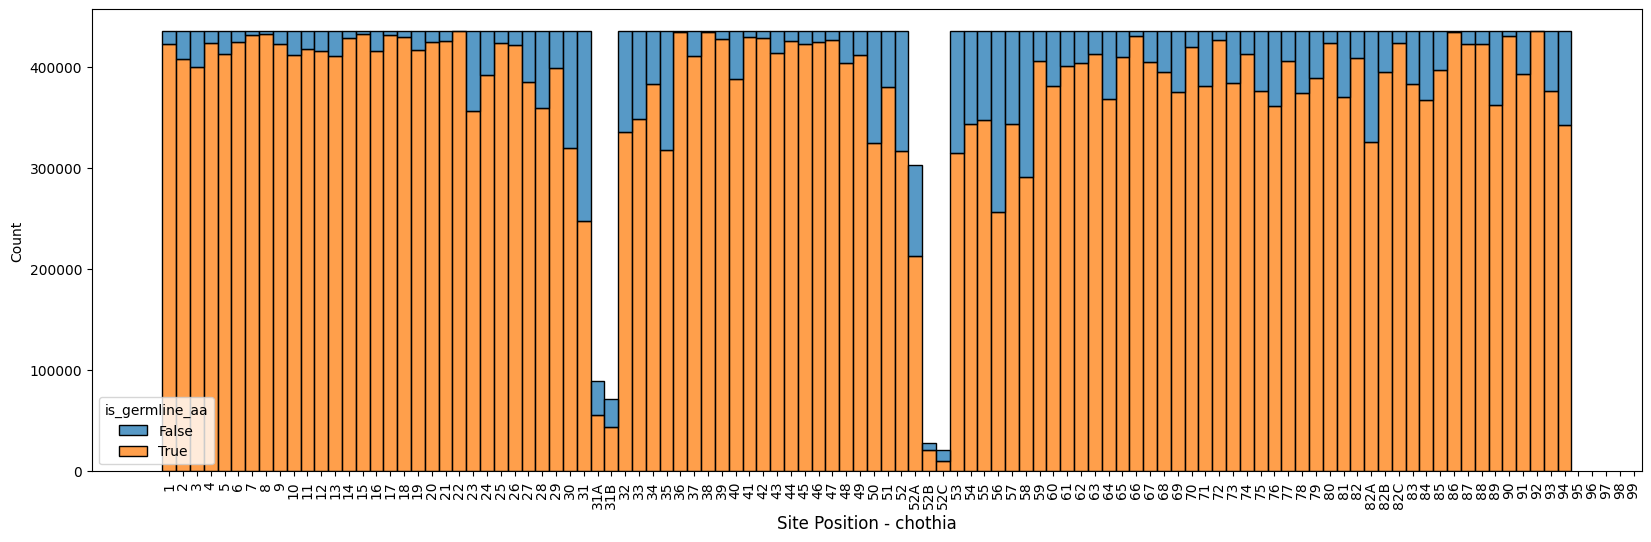

In [2]:
model_name = "dasm_4m-v1jaffeCC+v1tangCC-joint"
dataset_name = "v1rodriguez"
numbering_scheme = 'chothia'


germline_codons_df = pd.read_csv(GERMLINE_PATH_DICTIONARY[numbering_scheme], dtype={'site': str})


site_sub_probs_df, pcp_df, aa_site_subs_selection_df_germline = load_and_process_dasm_data(
    model_name=model_name,
    dataset_name=dataset_name,
    numbering_scheme=numbering_scheme,
    figures_dir="figures"
)


fig, ax = plt.subplots(figsize=(20,6))
sns.histplot(aa_site_subs_selection_df_germline, x='site', hue='is_germline_aa', multiple='stack', ax=ax)
ax.set_xlabel(f'Site Position - {numbering_scheme}', fontsize=12)
ax.tick_params(axis='x', rotation=90)


In [3]:
# Get all unique amino acids to create consistent color palette
PALETTE_AA = dict(zip(AA_STR_SORTED, sns.color_palette('tab20', len(AA_STR_SORTED))))


# output dir for results
output_dir = f'_output/entrenchment_analysis/{numbering_scheme}/'
os.makedirs(output_dir, exist_ok=True)


# when comparing v families/genes, let's split the sites into two groups:
- group 1 - sites with the same germline amino acid in both v families/germline_results
- group 2 - sites where the germline amino acids are different in the two v families/germline_results

As can be seen in the plots below, when we are comparing two genes, then every site is either in group 1 or 2.
But when we compare two v families, we have multiple options per site, some of these also exist in the other v family and some do not.

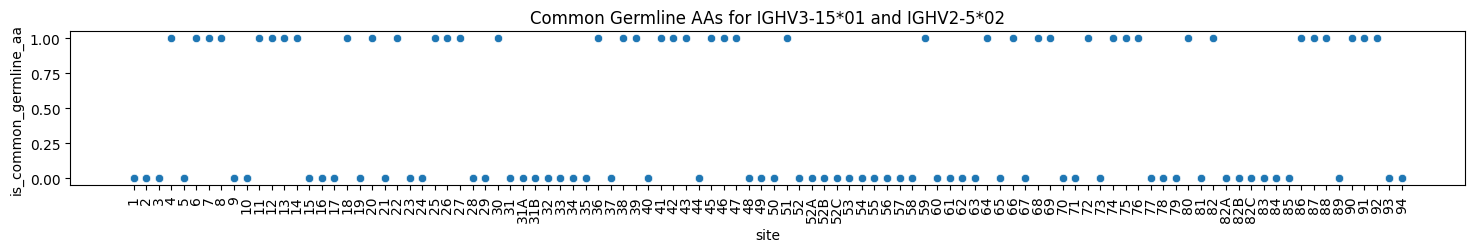

In [4]:
v_genes = ['IGHV3-15*01', 'IGHV2-5*02']
temp_df = pd.merge(germline_codons_df[germline_codons_df.v_gene == v_genes[0]], germline_codons_df[germline_codons_df.v_gene == v_genes[1]], on=['site', 'amino_acid'], how='outer', suffixes=('_1', '_2'))
temp_df['is_common_germline_aa'] = (temp_df['codon_1'].isna() == False) & (temp_df['codon_2'].isna() == False)
temp_df

# Sort the dataframe by site using sort_antibody_sites
sorted_sites = sort_antibody_sites(temp_df['site'].unique())
temp_df['site'] = pd.Categorical(temp_df['site'], categories=sorted_sites, ordered=True)
temp_df = temp_df.sort_values('site')

fig, ax = plt.subplots(1, 1, figsize=(18, 2))
sns.scatterplot(temp_df, x='site', y='is_common_germline_aa', ax=ax)
ax.set_title(f'Common Germline AAs for {v_genes[0]} and {v_genes[1]}')
ax.tick_params(axis='x', rotation=90) 



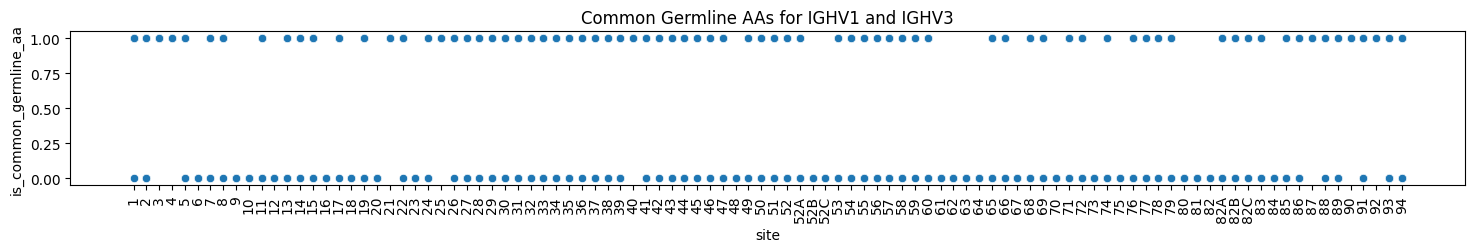

In [5]:
v_families = ['IGHV1', 'IGHV3']
temp_df = pd.merge(germline_codons_df[germline_codons_df.v_family == v_families[0]], germline_codons_df[germline_codons_df.v_family == v_families[1]], on=['site', 'amino_acid'], how='outer', suffixes=('_1', '_2'))
temp_df['is_common_germline_aa'] = (temp_df['codon_1'].isna() == False) & (temp_df['codon_2'].isna() == False)
temp_df

# Sort the dataframe by site using sort_antibody_sites
sorted_sites = sort_antibody_sites(temp_df['site'].unique())
temp_df['site'] = pd.Categorical(temp_df['site'], categories=sorted_sites, ordered=True)
temp_df = temp_df.sort_values('site')

fig, ax = plt.subplots(1, 1, figsize=(18, 2))
sns.scatterplot(temp_df, x='site', y='is_common_germline_aa', ax=ax)
ax.set_title(f'Common Germline AAs for {v_families[0]} and {v_families[1]}')
ax.tick_params(axis='x', rotation=90) 

## Group 1 sites - identical germline identity

In [6]:
## tools for comparing two groups (can be full v families or just two v genes)


def compare_v_families_group_1(aa_site_subs_selection_df_germline, v_family1, v_family2, create_plots=True, vcolumn='v_family', is_germline=True, one_mutation_away=True, lower_log_selection_factor_lim=-5, limit_pcp_depth=True):
    '''
    vcolumn: column to use for v family comparison, e.g. 'v_family' or 'v_gene'
    '''
    before_grouping = aa_site_subs_selection_df_germline.copy()
    if limit_pcp_depth:
        # Limit to only pcps that are 2 levels away from the naive, which are likely the most reliable
        before_grouping = before_grouping[before_grouping.depth == 2]

    if one_mutation_away:
        # Filter to only include mutations that are one mutation away        
        before_grouping = before_grouping[before_grouping['one_mutation_away'] == True]

    if is_germline:
        before_grouping = before_grouping[before_grouping.is_germline_codon == True]

    median_log_selection_factors_1 = before_grouping[(before_grouping[vcolumn] == v_family1)].groupby(['site', 'parent_aa', 'selection_factor_target_aa', 'is_cdr']).log_selection_factor.median().reset_index().copy()
    median_log_selection_factors_2 = before_grouping[(before_grouping[vcolumn] == v_family2)].groupby(['site', 'parent_aa', 'selection_factor_target_aa', 'is_cdr']).log_selection_factor.median().reset_index().copy()
    median_log_selection_factors_compare = pd.merge(median_log_selection_factors_1, median_log_selection_factors_2, on=['site', 'parent_aa', 'selection_factor_target_aa', 'is_cdr'], how='inner', suffixes=('_1', '_2'))

    median_log_selection_factors_compare = median_log_selection_factors_compare[median_log_selection_factors_compare.isna().any(axis=1) == False]
    median_log_selection_factors_compare['log_selection_factor_1'] = median_log_selection_factors_compare['log_selection_factor_1'].clip(lower=lower_log_selection_factor_lim)
    median_log_selection_factors_compare['log_selection_factor_2'] = median_log_selection_factors_compare['log_selection_factor_2'].clip(lower=lower_log_selection_factor_lim)

    median_log_selection_factors_compare['abs_difference'] = (median_log_selection_factors_compare['log_selection_factor_1'] - median_log_selection_factors_compare['log_selection_factor_2']).abs()
    median_log_selection_factors_compare['difference'] = (median_log_selection_factors_compare['log_selection_factor_2'] - median_log_selection_factors_compare['log_selection_factor_1'])

    if create_plots:
        plot_dasm_regression(median_log_selection_factors_compare, lower_log_selection_factor_lim=lower_log_selection_factor_lim, v_family1=v_family1, v_family2=v_family2)
        plot_dasm_effect_vs_shift(median_log_selection_factors_compare, lower_log_selection_factor_lim=lower_log_selection_factor_lim, v_family1=v_family1, v_family2=v_family2)
        plot_site_comparison(median_log_selection_factors_compare, lower_log_selection_factor_lim=lower_log_selection_factor_lim)
        plot_differences_per_region(median_log_selection_factors_compare)
        plot_epistasis_by_amino_acid(median_log_selection_factors_compare)
        plot_epistasis_by_amino_acid_flagged(median_log_selection_factors_compare)
        plot_epistasis_by_amino_acid_heatmap(median_log_selection_factors_compare)
        plot_epistasis_by_amino_acid_heatmap_flagged(median_log_selection_factors_compare)


    return median_log_selection_factors_compare

def plot_dasm_regression(median_log_selection_factors_compare, v_family1='v_family1', 
                         v_family2='v_family2', lower_log_selection_factor_lim=-5, 
                         ax=None, apply_filter=False):
    """
    Plot regression comparison between two v_families with epistatic effects highlighted.
    
    Parameters:
    -----------
    ax : matplotlib.axes.Axes, optional
        If provided, plot on this axes. Otherwise create new figure.
    apply_filter : bool, default False
        If True, filter data by lower_log_selection_factor_lim
    
    Returns:
    --------
    ax : matplotlib.axes.Axes
    r_squared : float
    """
    df = median_log_selection_factors_compare.copy()
    
    # Apply filtering if requested
    if apply_filter:
        df = df[(df['log_selection_factor_1'] > lower_log_selection_factor_lim) & 
                (df['log_selection_factor_2'] > lower_log_selection_factor_lim)]
    
    # Define significance criteria for epistatic effects
    df['is_significant'] = (
        ((df['log_selection_factor_2'] * df['log_selection_factor_1'] < 0) & 
         (df['abs_difference'] > 1)) | 
        (df['abs_difference'] > 2)
    )
    
    # Split data into significant and non-significant
    significant_df = df[df['is_significant']]
    non_significant_df = df[~df['is_significant']]
    
    # Calculate R-squared for all points
    r, p = pearsonr(df['log_selection_factor_1'], df['log_selection_factor_2'])
    r_squared = r**2
    
    # Create axes if not provided
    if ax is None:
        fig, ax = plt.subplots(figsize=(7, 6))
    
    # Plot non-significant points first (gray)
    ax.scatter(non_significant_df['log_selection_factor_1'], 
              non_significant_df['log_selection_factor_2'],
              alpha=0.4, s=30, edgecolors='none', c='grey', label='Non-significant')
    
    # Plot significant points on top (red)
    ax.scatter(significant_df['log_selection_factor_1'], 
              significant_df['log_selection_factor_2'],
              alpha=0.6, s=30, edgecolors='none', c='red', label='Epistatic')
    
    # Add x=y line
    xlim = ax.get_xlim()
    ylim = ax.get_ylim()
    lims = [max(xlim[0], ylim[0]), min(xlim[1], ylim[1])]
    ax.plot(lims, lims, 'k--', alpha=0.5, linewidth=2, label='x=y')
    
    # Labels and title
    ax.set_xlabel(f'{v_family1} Log Selection Factor', fontsize=11)
    ax.set_ylabel(f'{v_family2} Log Selection Factor', fontsize=11)
    
    filter_text = f' (>{lower_log_selection_factor_lim})' if apply_filter else ''
    ax.set_title(f'{v_family1} vs {v_family2}{filter_text}\nR² = {r_squared:.3f}', fontsize=12)
    
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)
    
    if ax is None:
        plt.tight_layout()
    
    return ax, r_squared


def plot_dasm_effect_vs_shift(median_log_selection_factors_compare, 
                               v_family1='v_family1', v_family2='v_family2',
                               lower_log_selection_factor_lim=-5, 
                               ax=None, apply_filter=True):
    """
    Plot log selection factor vs difference/shift.
    Now plots only filtered version by default (removed dual plotting).
    
    Parameters:
    -----------
    ax : matplotlib.axes.Axes, optional
        If provided, plot on this axes. Otherwise create new figure.
    apply_filter : bool, default True
        If True, filter data by lower_log_selection_factor_lim
    
    Returns:
    --------
    ax : matplotlib.axes.Axes
    """
    df = median_log_selection_factors_compare.copy()
    
    # Apply filtering if requested
    if apply_filter:
        df = df[(df['log_selection_factor_1'] > lower_log_selection_factor_lim) & 
                (df['log_selection_factor_2'] > lower_log_selection_factor_lim)]
    
    # Create axes if not provided
    if ax is None:
        fig, ax = plt.subplots(figsize=(7, 6))
    
    # Scatter plot with alpha for visibility
    ax.scatter(df['log_selection_factor_1'], df['difference'], 
              alpha=0.3, s=30, edgecolors='none', c='steelblue')
    
    # Labels
    ax.set_xlabel(f'{v_family1} Log Selection Factor', fontsize=11)
    ax.set_ylabel(f'Difference ({v_family2} - {v_family1})', fontsize=11)
    
    filter_text = f' (>{lower_log_selection_factor_lim})' if apply_filter else ''
    ax.set_title(f'{v_family1} Selection Factor vs Shift to {v_family2}{filter_text}', 
                fontsize=12)
    
    ax.grid(True, alpha=0.3)
    ax.axhline(y=0, color='r', linestyle='--', alpha=0.5, linewidth=1.5, label='No change')
    ax.legend()
    
    if ax is None:
        plt.tight_layout()
    
    return ax

def plot_site_comparison(median_log_selection_factors_compare, 
                        lower_log_selection_factor_lim=-5, ax=None, numbering_scheme=numbering_scheme):
    """
    Plot absolute differences by site with CDR background and epistatic effects highlighted.
    
    Returns:
    --------
    ax : matplotlib.axes.Axes
    df : pd.DataFrame
    """
    df = median_log_selection_factors_compare.copy()
    site_count = len(df['site'].drop_duplicates())
    
    # Define significance criteria for epistatic effects
    df['is_significant'] = (
        ((df['log_selection_factor_2'] * df['log_selection_factor_1'] < 0) & 
         (df['abs_difference'] > 1)) | 
        (df['abs_difference'] > 2)
    )
    
    # Sort the dataframe by site using sort_antibody_sites
    sorted_sites = sort_antibody_sites(df['site'].unique())
    df['site'] = pd.Categorical(df['site'], categories=sorted_sites, ordered=True)
    df = df.sort_values('site')

    # Split data
    significant_df = df[df['is_significant']]
    non_significant_df = df[~df['is_significant']]
    
    # Create axes if not provided
    if ax is None:
        fig, ax = plt.subplots(figsize=(10, 6))
    
    add_cdr_shading(ax, sorted_sites, numbering_scheme=numbering_scheme)
    
    # Plot non-significant points
    ax.scatter(non_significant_df['site'], 
               non_significant_df['abs_difference'],
               alpha=0.5, s=40, c='lightgray', label='Non-significant')
    
    # Plot significant points
    ax.scatter(significant_df['site'], 
               significant_df['abs_difference'],
               alpha=0.7, s=40, c='red', label='Epistatic')
    
    ax.set_title(f'Absolute Difference in Log Selection Factors by Site (n={site_count})')
    ax.set_xlabel('Site')
    ax.set_ylabel('Absolute Difference')
    ax.legend(loc='upper right', fontsize=9)
    ax.grid(True, alpha=0.3, axis='y')
    ax.tick_params(axis='x', rotation=90) 

    
    if ax is None:
        plt.tight_layout()
    
    return ax, df


def plot_differences_per_region(median_log_selection_factors_compare, ax=None):
    """
    Plot histograms of absolute differences for CDR vs FWR regions.
    
    Returns:
    --------
    ax : matplotlib.axes.Axes
    """
    df = median_log_selection_factors_compare.copy()
    
    # Create axes if not provided
    if ax is None:
        fig, ax = plt.subplots(1, 1, figsize=(6, 4))
    
    # Use ax.hist() instead of pandas .hist() to avoid figure conflicts
    cdr_data = df[df.is_cdr == True].abs_difference.dropna()
    fwr_data = df[df.is_cdr == False].abs_difference.dropna()
    
    ax.hist(cdr_data, bins=50, alpha=0.5, label='CDR')
    ax.hist(fwr_data, bins=50, alpha=0.5, label='FWR')
    
    ax.legend()
    ax.set_title('Absolute Difference in Log Selection Factors')
    ax.set_xlabel('Absolute Difference')
    ax.set_ylabel('Count')
    
    if ax is None:
        plt.tight_layout()
    
    return ax


def plot_epistasis_by_amino_acid(median_log_selection_factors_compare, 
                                 figsize=(6, 5), ax=None):
    """
    Plot showing both counts and percentages of significant epistatic sites per amino acid.
    
    Returns:
    --------
    ax : matplotlib.axes.Axes
    summary_df : pd.DataFrame
    """
    df = median_log_selection_factors_compare.copy()
    
    # Calculate statistics
    total_by_aa = df[['parent_aa', 'site']].drop_duplicates().groupby('parent_aa').size()
    sig_by_aa = df[((df.log_selection_factor_2 * df.log_selection_factor_1 < 0) & 
                    (df.abs_difference > 1)) | (df.abs_difference > 2)][
                        ['site', 'parent_aa']].drop_duplicates().groupby('parent_aa').size()
    
    # Create summary dataframe
    summary_df = pd.DataFrame({
        'total_sites': total_by_aa,
        'significant_sites': sig_by_aa.fillna(0).astype(int),
        'percentage_significant': (sig_by_aa / total_by_aa * 100).fillna(0)
    }).sort_values('percentage_significant', ascending=True)
    
    # Create axes if not provided
    if ax is None:
        fig, ax = plt.subplots(figsize=figsize)
    
    # Create horizontal bar plot
    y_pos = np.arange(len(summary_df))
    bars = ax.barh(y_pos, summary_df['percentage_significant'], 
                   color='steelblue', alpha=0.7, edgecolor='black', linewidth=0.5)
    
    # Add text annotations
    for i, (aa, row) in enumerate(summary_df.iterrows()):
        sig_count = int(row['significant_sites']) if not pd.isna(row['significant_sites']) else 0
        total_count = int(row['total_sites'])
        ax.text(row['percentage_significant'] + 1, i, 
                f"{sig_count}/{total_count}", 
                va='center', ha='left', fontsize=9, fontweight='bold')
    
    # Customize
    ax.set_yticks(y_pos)
    ax.set_yticklabels(summary_df.index, fontsize=11)
    ax.set_xlabel('Percentage of Sites (sign flip & |diff|>1 or |diff|>2)', fontsize=10)
    ax.set_ylabel('Amino Acid', fontsize=11)
    ax.set_title('Epistatic Effects by Parent Amino Acid', fontsize=12)
    ax.grid(True, alpha=0.3, axis='x')
    ax.set_xlim(0, max(summary_df['percentage_significant']) * 1.2)
    
    if ax is None:
        plt.tight_layout()
    
    return ax, summary_df



def plot_epistasis_by_amino_acid_heatmap(median_log_selection_factors_compare, 
                                        figsize=(12, 10), ax=None):
    """
    Heatmap showing percentage of significant epistatic sites.
    
    Returns:
    --------
    ax : matplotlib.axes.Axes
    summary_df : pd.DataFrame
    heatmap_data : pd.DataFrame
    """
    df = median_log_selection_factors_compare.copy()
    
    # Calculate statistics
    total_by_sub = df[['parent_aa', 'selection_factor_target_aa', 'site']].drop_duplicates(
        ).groupby(['parent_aa', 'selection_factor_target_aa']).size()
    sig_by_sub = df[((df.log_selection_factor_2 * df.log_selection_factor_1 < 0) & 
                     (df.abs_difference > 1)) | (df.abs_difference > 2)][
                         ['site', 'parent_aa', 'selection_factor_target_aa']].drop_duplicates(
                             ).groupby(['parent_aa', 'selection_factor_target_aa']).size()
    
    summary_df = pd.DataFrame({
        'total_sites': total_by_sub,
        'significant_sites': sig_by_sub.fillna(0).astype(int),
        'percentage_significant': (sig_by_sub / total_by_sub * 100).fillna(0)
    }).reset_index()
    
    # Create pivot tables
    heatmap_data = summary_df.pivot(index='parent_aa', columns='selection_factor_target_aa', 
                                    values='percentage_significant')
    
    annotation_data = summary_df.copy()
    annotation_data['significant_sites'] = annotation_data['significant_sites'].fillna(0).astype(int)
    annotation_data['total_sites'] = annotation_data['total_sites'].fillna(0).astype(int)
    annotation_data['ratio_text'] = (annotation_data['significant_sites'].astype(str) + '/' + 
                                     annotation_data['total_sites'].astype(str))
    annotation_matrix = annotation_data.pivot(index='parent_aa', 
                                             columns='selection_factor_target_aa', 
                                             values='ratio_text')
    
    # Create axes if not provided
    if ax is None:
        fig, ax = plt.subplots(figsize=figsize)
    
    # Create heatmap
    im = ax.imshow(heatmap_data.values, cmap='YlOrRd', aspect='auto', vmin=0)
    
    # Add colorbar (only if creating own figure)
    if ax is None:
        cbar = plt.colorbar(im, ax=ax)
        cbar.set_label('Percentage of Significant Sites (%)', fontsize=12)
    
    # Set ticks and labels
    ax.set_xticks(np.arange(len(heatmap_data.columns)))
    ax.set_yticks(np.arange(len(heatmap_data.index)))
    ax.set_xticklabels(heatmap_data.columns, fontsize=10)
    ax.set_yticklabels(heatmap_data.index, fontsize=10)
    plt.setp(ax.get_xticklabels(), rotation=0, ha="center")
    
    # Add text annotations
    for i in range(len(heatmap_data.index)):
        for j in range(len(heatmap_data.columns)):
            parent = heatmap_data.index[i]
            target = heatmap_data.columns[j]
            if parent in annotation_matrix.index and target in annotation_matrix.columns:
                text_val = annotation_matrix.loc[parent, target]
                if pd.notna(text_val):
                    percentage = heatmap_data.iloc[i, j]
                    text_color = 'white' if pd.notna(percentage) and percentage > 50 else 'black'
                    ax.text(j, i, text_val, ha="center", va="center", 
                           color=text_color, fontsize=8, fontweight='bold')
    
    # Labels
    ax.set_xlabel('Target Amino Acid', fontsize=11, fontweight='bold')
    ax.set_ylabel('Parent Amino Acid', fontsize=11, fontweight='bold')
    ax.set_title('Epistatic Effects by AA Substitution', fontsize=12, fontweight='bold')
    
    if ax is None:
        plt.tight_layout()
    
    return ax, summary_df, heatmap_data

import scipy.stats as stats
from statsmodels.stats.multitest import multipletests
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

def plot_epistasis_by_amino_acid_heatmap_flagged(median_log_selection_factors_compare, 
                                        figsize=(12, 10), ax=None,
                                        min_observations_enriched=3,
                                        enriched_threshold=0.30,  # 30%
                                        min_observations_depleted=5,
                                        depleted_threshold=0.0,   # 0%
                                        run_fisher=True,
                                        fdr_threshold=0.10):
    """
    Heatmap showing epistatic effects with practical thresholds for exploratory analysis.
    
    Parameters:
    -----------
    median_log_selection_factors_compare : pd.DataFrame
        Input data
    figsize : tuple
        Figure size if ax not provided
    ax : matplotlib.axes.Axes
        Existing axes to plot on
    min_observations_enriched : int
        Minimum observations to call enriched (default 3)
    enriched_threshold : float
        Percentage threshold for enrichment (default 0.30 = 30%)
    min_observations_depleted : int
        Minimum observations to call depleted (default 5)
    depleted_threshold : float
        Percentage threshold for depletion (default 0.0 = 0%)
    run_fisher : bool
        Whether to also run Fisher's exact test (for reference)
    fdr_threshold : float
        FDR threshold if running Fisher's test
    
    Returns:
    --------
    ax : matplotlib.axes.Axes
    summary_df : pd.DataFrame with results
    heatmap_data : pd.DataFrame
    """
    df = median_log_selection_factors_compare.copy()
    
    # Calculate statistics
    total_by_sub = df[['parent_aa', 'selection_factor_target_aa', 'site']].drop_duplicates(
        ).groupby(['parent_aa', 'selection_factor_target_aa']).size()
    sig_by_sub = df[((df.log_selection_factor_2 * df.log_selection_factor_1 < 0) & 
                     (df.abs_difference > 1)) | (df.abs_difference > 2)][
                         ['site', 'parent_aa', 'selection_factor_target_aa']].drop_duplicates(
                             ).groupby(['parent_aa', 'selection_factor_target_aa']).size()
    
    summary_df = pd.DataFrame({
        'total_sites': total_by_sub,
        'significant_sites': sig_by_sub.fillna(0).astype(int),
        'percentage_significant': (sig_by_sub / total_by_sub * 100).fillna(0)
    }).reset_index()
    
    summary_df['significant_sites'] = summary_df['significant_sites'].fillna(0).astype(int)
    summary_df['total_sites'] = summary_df['total_sites'].astype(int)
    summary_df['rate'] = summary_df['significant_sites'] / summary_df['total_sites']
    
    # Calculate background rate
    total_all_sites = summary_df['total_sites'].sum()
    total_all_sig = summary_df['significant_sites'].sum()
    background_rate = total_all_sig / total_all_sites if total_all_sites > 0 else 0
    
    # Apply practical thresholds
    def classify_substitution(row):
        if row['rate'] >= enriched_threshold and row['total_sites'] >= min_observations_enriched:
            return 'enriched'
        elif row['rate'] <= depleted_threshold and row['total_sites'] >= min_observations_depleted:
            return 'depleted'
        else:
            return 'not_flagged'
    
    summary_df['interpretation'] = summary_df.apply(classify_substitution, axis=1)
    summary_df['is_flagged'] = summary_df['interpretation'].isin(['enriched', 'depleted'])
    
    # Optionally run Fisher's exact test for reference
    if run_fisher:
        p_values = []
        odds_ratios = []
        
        for idx, row in summary_df.iterrows():
            if row['total_sites'] < 2:  # Need at least 2 observations
                p_values.append(np.nan)
                odds_ratios.append(np.nan)
                continue
                
            sig_this = int(row['significant_sites'])
            total_this = int(row['total_sites'])
            nonsig_this = total_this - sig_this
            
            sig_background = total_all_sig - sig_this
            total_background = total_all_sites - total_this
            nonsig_background = total_background - sig_background
            
            if nonsig_this < 0 or sig_background < 0 or nonsig_background < 0 or total_background <= 0:
                p_values.append(np.nan)
                odds_ratios.append(np.nan)
                continue
            
            contingency_table = np.array([[sig_this, nonsig_this],
                                         [sig_background, nonsig_background]], dtype=int)
            
            try:
                odds_ratio, p_value = stats.fisher_exact(contingency_table)
                p_values.append(p_value)
                odds_ratios.append(odds_ratio)
            except Exception as e:
                p_values.append(np.nan)
                odds_ratios.append(np.nan)
        
        summary_df['fisher_p_value'] = p_values
        summary_df['odds_ratio'] = odds_ratios
        
        # FDR correction
        tested_mask = ~summary_df['fisher_p_value'].isna()
        tested_p_values = summary_df.loc[tested_mask, 'fisher_p_value'].values
        
        if len(tested_p_values) > 0:
            reject, corrected_p, _, _ = multipletests(tested_p_values, 
                                                       alpha=fdr_threshold, 
                                                       method='fdr_bh')
            summary_df.loc[tested_mask, 'fdr_corrected_p'] = corrected_p
            summary_df.loc[tested_mask, 'fdr_significant'] = reject
        else:
            summary_df['fdr_corrected_p'] = np.nan
            summary_df['fdr_significant'] = False
    
    # Create pivot tables
    heatmap_data = summary_df.pivot(index='parent_aa', columns='selection_factor_target_aa', 
                                    values='percentage_significant')
    
    # Create annotation text
    annotation_data = summary_df.copy()
    
    def make_annotation(row):
        text = f"{row['significant_sites']}/{row['total_sites']}"
        if row['interpretation'] == 'enriched':
            text += '\n★'  # Star for enriched
        elif row['interpretation'] == 'depleted':
            text += '\n◆'  # Diamond for depleted
        return text
    
    annotation_data['ratio_text'] = annotation_data.apply(make_annotation, axis=1)
    annotation_matrix = annotation_data.pivot(index='parent_aa', 
                                             columns='selection_factor_target_aa', 
                                             values='ratio_text')
    
    # Create axes if not provided
    create_own_fig = ax is None
    if ax is None:
        fig, ax = plt.subplots(figsize=figsize)
    
    # Create heatmap
    im = ax.imshow(heatmap_data.values, cmap='YlOrRd', aspect='auto', vmin=0)
    
    # Add colorbar
    if create_own_fig:
        cbar = plt.colorbar(im, ax=ax)
        cbar.set_label('Percentage of Sites (Sign Flip or |diff|>2)', fontsize=12)
    
    # Set ticks and labels
    ax.set_xticks(np.arange(len(heatmap_data.columns)))
    ax.set_yticks(np.arange(len(heatmap_data.index)))
    ax.set_xticklabels(heatmap_data.columns, fontsize=10)
    ax.set_yticklabels(heatmap_data.index, fontsize=10)
    plt.setp(ax.get_xticklabels(), rotation=0, ha="center")
    
    # Add text annotations
    for i in range(len(heatmap_data.index)):
        for j in range(len(heatmap_data.columns)):
            parent = heatmap_data.index[i]
            target = heatmap_data.columns[j]
            if parent in annotation_matrix.index and target in annotation_matrix.columns:
                text_val = annotation_matrix.loc[parent, target]
                if pd.notna(text_val):
                    percentage = heatmap_data.iloc[i, j]
                    text_color = 'white' if pd.notna(percentage) and percentage > 50 else 'black'
                    ax.text(j, i, text_val, ha="center", va="center", 
                           color=text_color, fontsize=7, fontweight='bold')
    
    # Labels
    ax.set_xlabel('Target Amino Acid', fontsize=11, fontweight='bold')
    ax.set_ylabel('Parent Amino Acid', fontsize=11, fontweight='bold')
    
    title = (f'Epistatic Effects by AA Substitution\n'
             f'(★ ≥{enriched_threshold:.0%} with n≥{min_observations_enriched}, '
             f'◆ ={depleted_threshold:.0%} with n≥{min_observations_depleted}, '
             f'Background: {background_rate:.1%})')
    ax.set_title(title, fontsize=11, fontweight='bold')
    
    if create_own_fig:
        plt.tight_layout()
    
    return ax, summary_df, heatmap_data


def plot_epistasis_by_amino_acid_flagged(median_log_selection_factors_compare, 
                                         figsize=(6, 5), ax=None,
                                         min_observations=5,
                                         enriched_threshold=40.0,
                                         depleted_threshold=20.0,
                                         show_background=True):
    """
    Plot showing counts and percentages of significant epistatic sites per amino acid.
    Flags amino acids as enriched (>40%, n≥5) or depleted (<20%, n≥5).
    
    Returns:
    --------
    ax : matplotlib.axes.Axes
    summary_df : pd.DataFrame
    """
    df = median_log_selection_factors_compare.copy()
    
    # Calculate statistics
    total_by_aa = df[['parent_aa', 'site']].drop_duplicates().groupby('parent_aa').size()
    sig_by_aa = df[((df.log_selection_factor_2 * df.log_selection_factor_1 < 0) & 
                    (df.abs_difference > 1)) | (df.abs_difference > 2)][
                        ['site', 'parent_aa']].drop_duplicates().groupby('parent_aa').size()
    
    # Create summary dataframe
    summary_df = pd.DataFrame({
        'total_sites': total_by_aa,
        'significant_sites': sig_by_aa.fillna(0).astype(int),
        'percentage_significant': (sig_by_aa / total_by_aa * 100).fillna(0)
    })
    
    # Calculate background rate
    total_all_sites = summary_df['total_sites'].sum()
    total_all_sig = summary_df['significant_sites'].sum()
    background_rate = (total_all_sig / total_all_sites * 100) if total_all_sites > 0 else 0
    
    # Classify amino acids based on thresholds
    def classify_aa(row):
        if row['total_sites'] >= min_observations:
            if row['percentage_significant'] > enriched_threshold:
                return 'enriched'
            elif row['percentage_significant'] < depleted_threshold:
                return 'depleted'
        return 'not_flagged'
    
    summary_df['classification'] = summary_df.apply(classify_aa, axis=1)
    
    # Sort by percentage for plotting
    summary_df = summary_df.sort_values('percentage_significant', ascending=True)
    
    # Print summary
    print(f"=== Classification Summary ===")
    print(f"Background rate: {background_rate:.1f}%")
    print(f"Enriched (>{enriched_threshold}% with n≥{min_observations}): "
          f"{(summary_df['classification'] == 'enriched').sum()}")
    print(f"Depleted (<{depleted_threshold}% with n≥{min_observations}): "
          f"{(summary_df['classification'] == 'depleted').sum()}")
    print(f"Not flagged: {(summary_df['classification'] == 'not_flagged').sum()}")
    
    # Create axes if not provided
    create_own_fig = ax is None
    if ax is None:
        fig, ax = plt.subplots(figsize=figsize)
    
    # Create horizontal bar plot with color coding
    y_pos = np.arange(len(summary_df))
    
    # Color bars based on classification
    colors = []
    for aa in summary_df.index:
        if summary_df.loc[aa, 'classification'] == 'enriched':
            colors.append('orangered')  # Red for enriched
        elif summary_df.loc[aa, 'classification'] == 'depleted':
            colors.append('cornflowerblue')  # Blue for depleted
        else:
            colors.append('lightgray')  # Gray for not flagged
    
    bars = ax.barh(y_pos, summary_df['percentage_significant'], 
                   color=colors, alpha=0.7, edgecolor='black', linewidth=0.5)
    
    # Add background line
    if show_background:
        ax.axvline(background_rate, color='black', linestyle='--', linewidth=2, 
                   label=f'Background: {background_rate:.1f}%', alpha=0.7)
        ax.legend(loc='lower right', fontsize=9)
    
    # Add text annotations
    for i, (aa, row) in enumerate(summary_df.iterrows()):
        sig_count = int(row['significant_sites']) if not pd.isna(row['significant_sites']) else 0
        total_count = int(row['total_sites'])
        
        # Base text
        text = f"{sig_count}/{total_count}"
        
        # Add marker for flagged amino acids
        if row['classification'] == 'enriched':
            text += " ★"
        elif row['classification'] == 'depleted':
            text += " ◆"
        
        ax.text(row['percentage_significant'] + 1, i, text, 
                va='center', ha='left', fontsize=9, fontweight='bold')
    
    # Customize
    ax.set_yticks(y_pos)
    ax.set_yticklabels(summary_df.index, fontsize=11)
    ax.set_xlabel('Percentage of Sites (sign flip & |diff|>1 or |diff|>2)', fontsize=10)
    ax.set_ylabel('Amino Acid', fontsize=11)
    
    title = (f'Epistatic Effects by Parent Amino Acid\n'
             f'(★ >{enriched_threshold:.0f}% with n≥{min_observations}, '
             f'◆ <{depleted_threshold:.0f}% with n≥{min_observations})')
    ax.set_title(title, fontsize=11)
    ax.grid(True, alpha=0.3, axis='x')
    ax.set_xlim(0, max(summary_df['percentage_significant']) * 1.2)
    
    if create_own_fig:
        plt.tight_layout()
    
    return ax, summary_df, background_rate

=== Classification Summary ===
Background rate: 25.5%
Enriched (>40.0% with n≥5): 3
Depleted (<20.0% with n≥5): 5
Not flagged: 12


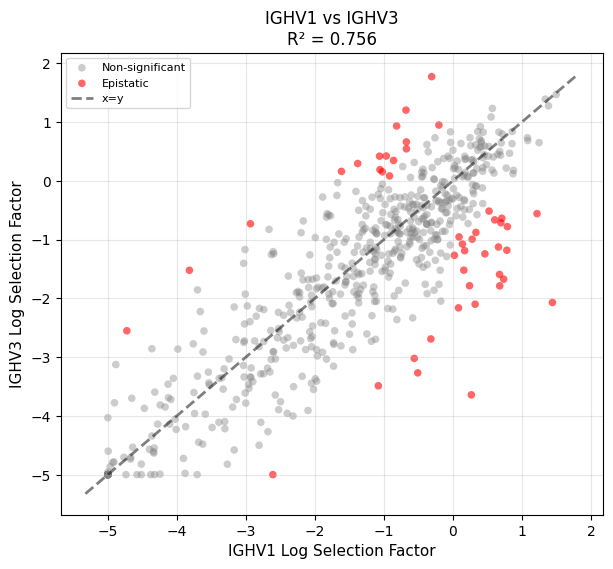

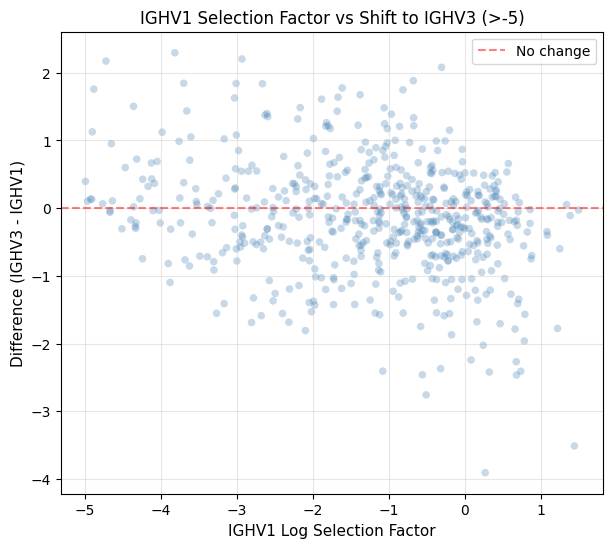

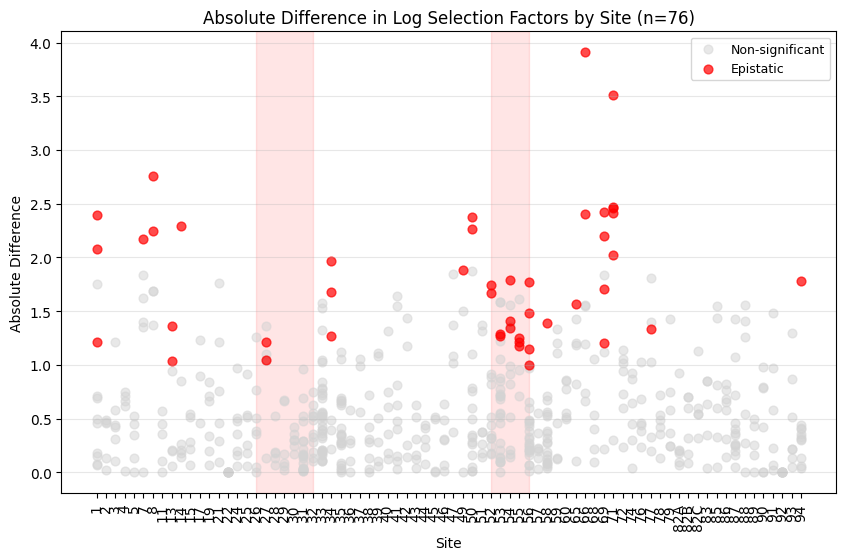

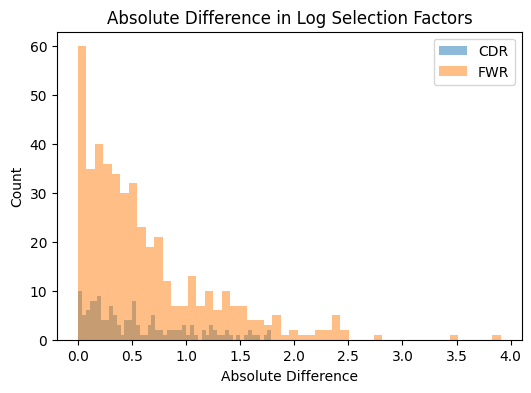

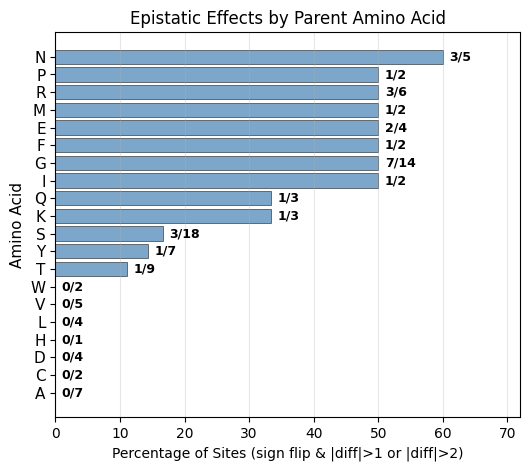

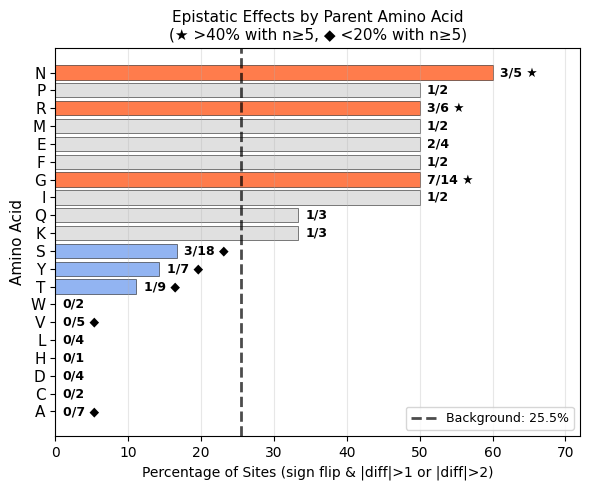

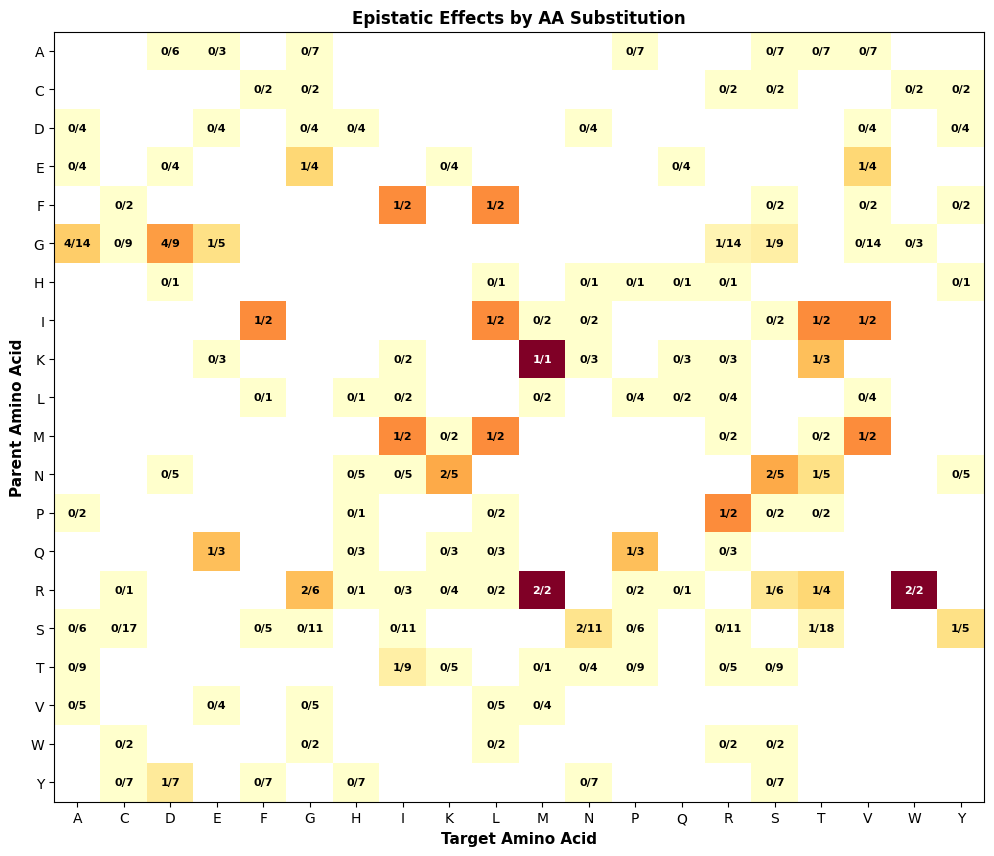

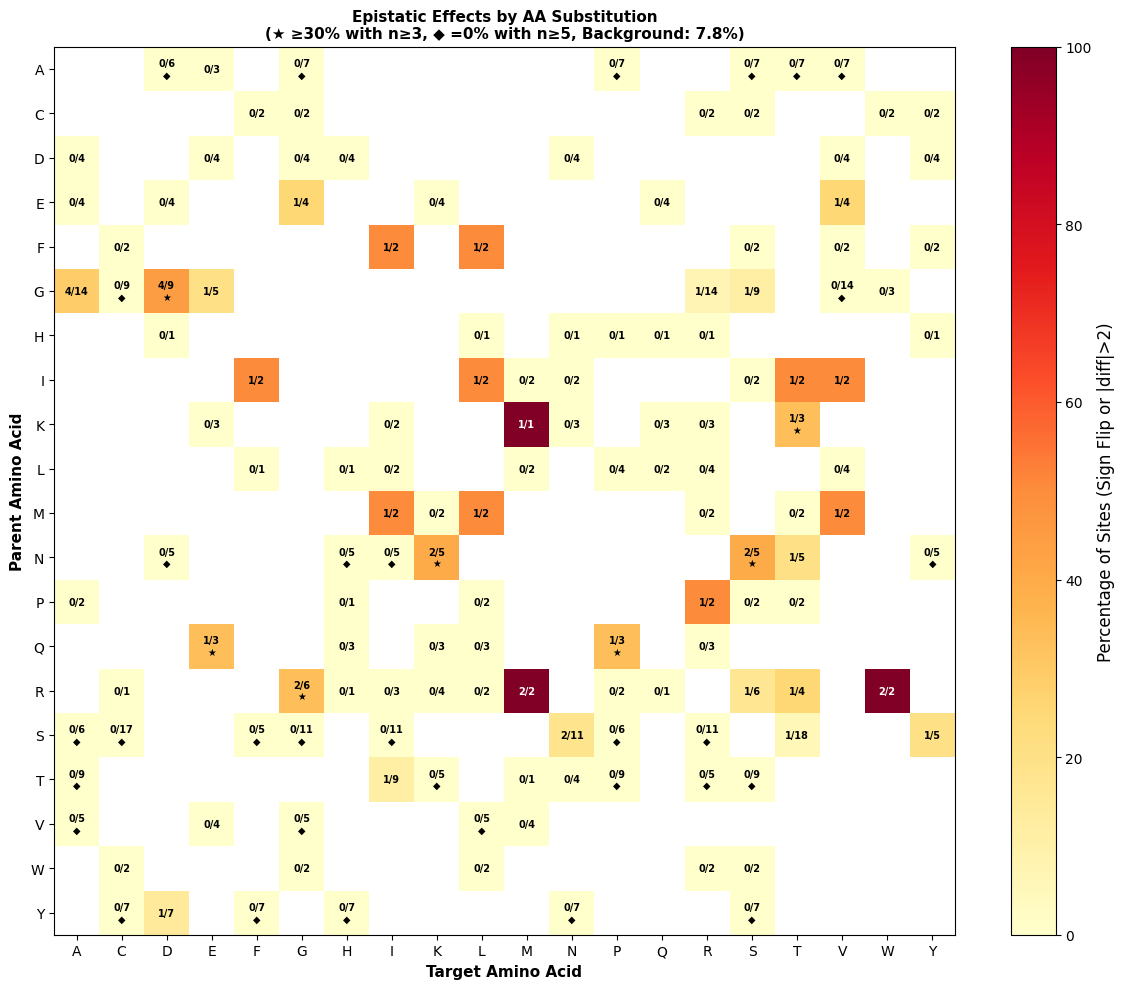

In [7]:
# IGHV1 vs IGHV3
cur_df = compare_v_families_group_1(aa_site_subs_selection_df_germline, 'IGHV1', 'IGHV3', one_mutation_away=True, is_germline=True, limit_pcp_depth=True)

=== Classification Summary ===
Background rate: 11.8%
Enriched (>40.0% with n≥5): 0
Depleted (<20.0% with n≥5): 5
Not flagged: 14


,site,parent_aa,selection_factor_target_aa,is_cdr,log_selection_factor_1,log_selection_factor_2,abs_difference,difference
0,1,E,A,False,-0.819511,-0.649533,0.169978,0.169978
1,1,E,D,False,-0.257771,-0.458621,0.200851,-0.200851
3,1,E,G,False,-0.906998,-0.935015,0.028018,-0.028018
4,1,E,K,False,-2.214090,-2.126016,0.088075,0.088075
5,1,E,Q,False,0.400619,0.692269,0.291650,0.291650
...,...,...,...,...,...,...,...,...
484,92,C,G,False,-5.000000,-5.000000,0.000000,0.000000
485,92,C,R,False,-5.000000,-5.000000,0.000000,0.000000
486,92,C,S,False,-5.000000,-5.000000,0.000000,0.000000
487,92,C,W,False,-5.000000,-5.000000,0.000000,0.000000


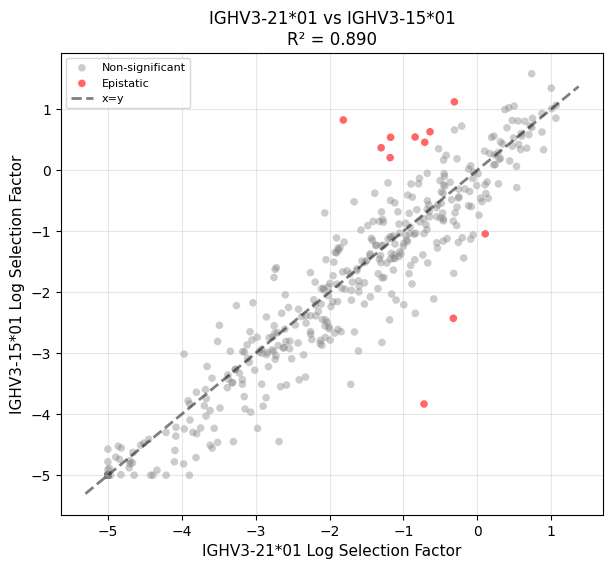

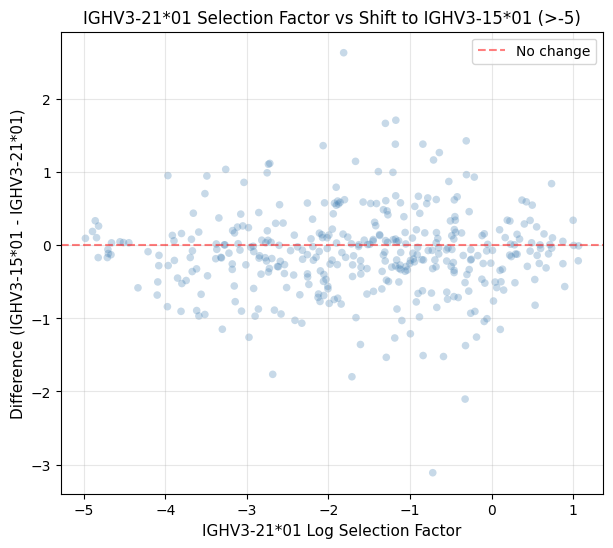

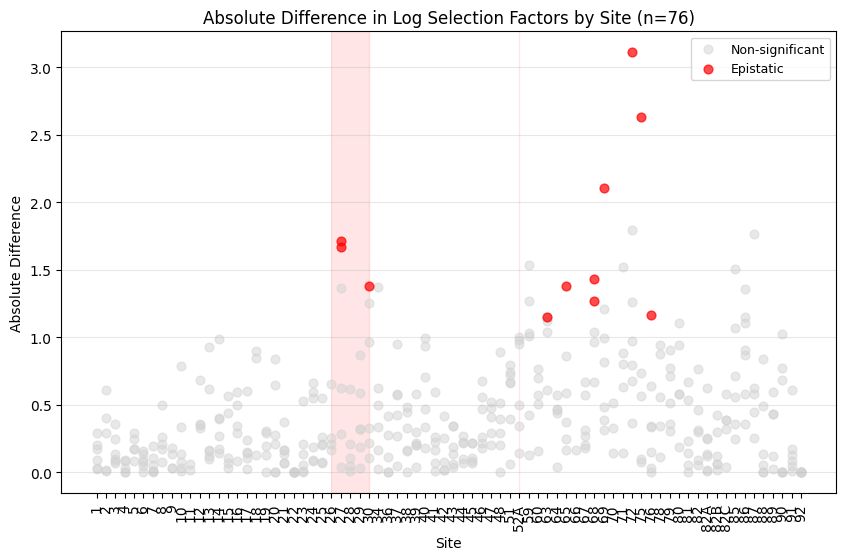

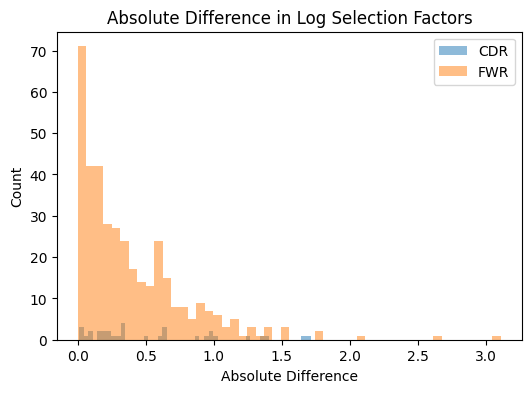

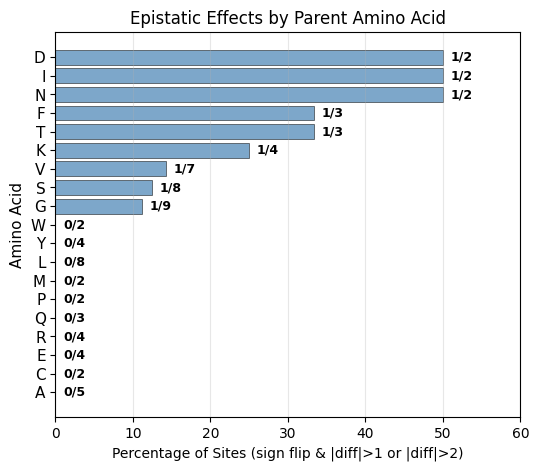

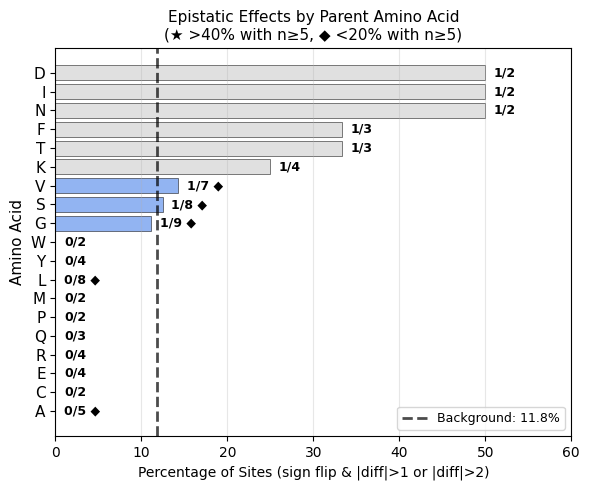

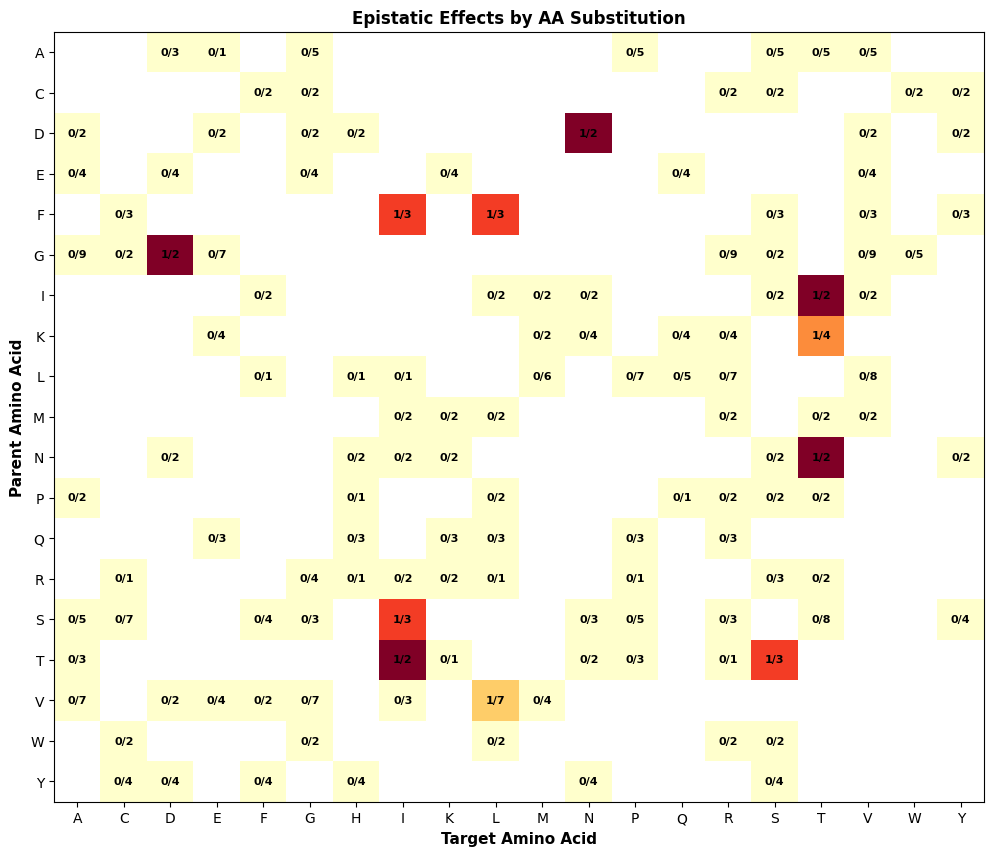

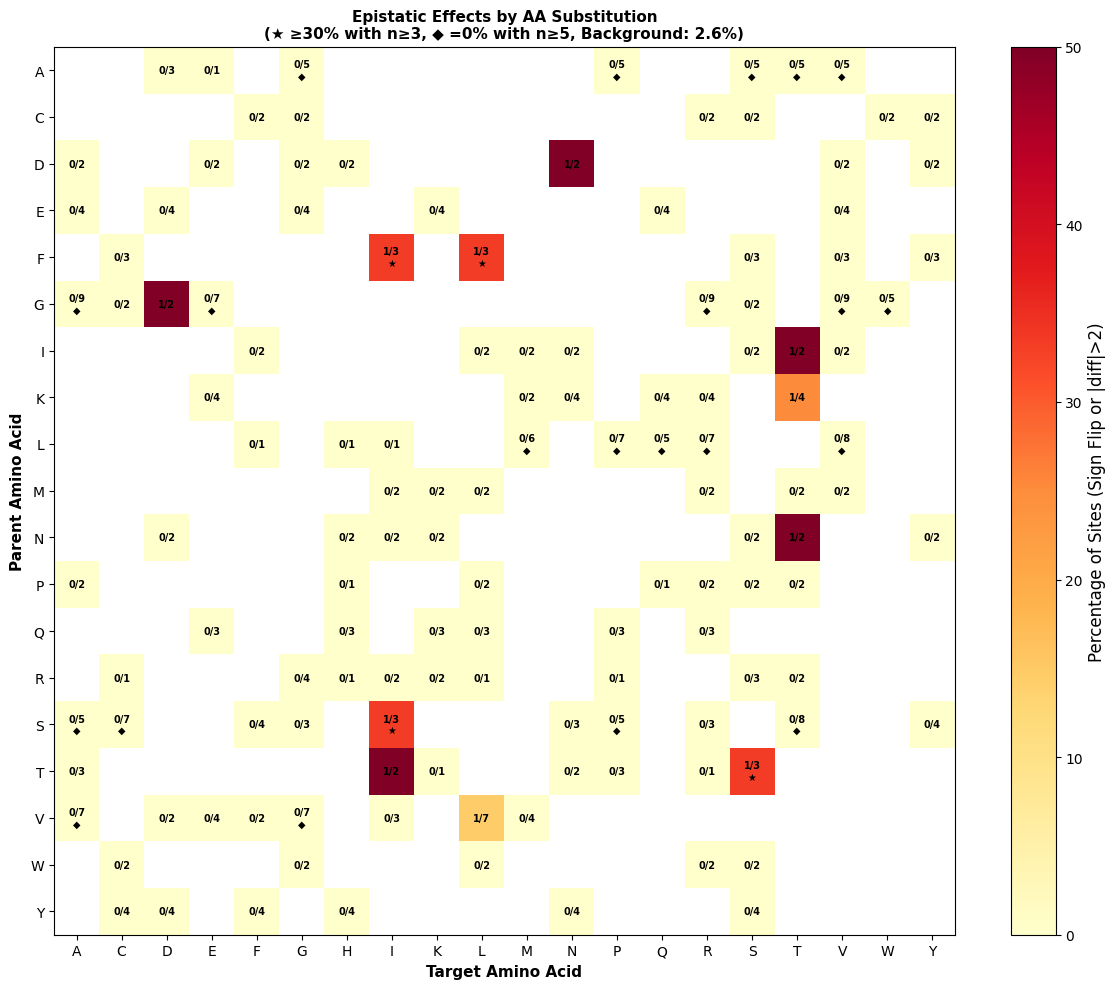

In [8]:
# compare two v genes within the same family
compare_v_families_group_1(aa_site_subs_selection_df_germline, 'IGHV3-21*01', 'IGHV3-15*01', vcolumn='v_gene', one_mutation_away=True, is_germline=True, limit_pcp_depth=True)


Processing comparison: IGHV1 vs IGHV3
=== Classification Summary ===
Background rate: 25.5%
Enriched (>40.0% with n≥5): 3
Depleted (<20.0% with n≥5): 5
Not flagged: 12
Processing comparison: IGHV3 vs IGHV4
=== Classification Summary ===
Background rate: 25.3%
Enriched (>40.0% with n≥5): 0
Depleted (<20.0% with n≥5): 3
Not flagged: 16
Processing comparison: IGHV1 vs IGHV4
=== Classification Summary ===
Background rate: 29.2%
Enriched (>40.0% with n≥5): 1
Depleted (<20.0% with n≥5): 1
Not flagged: 17


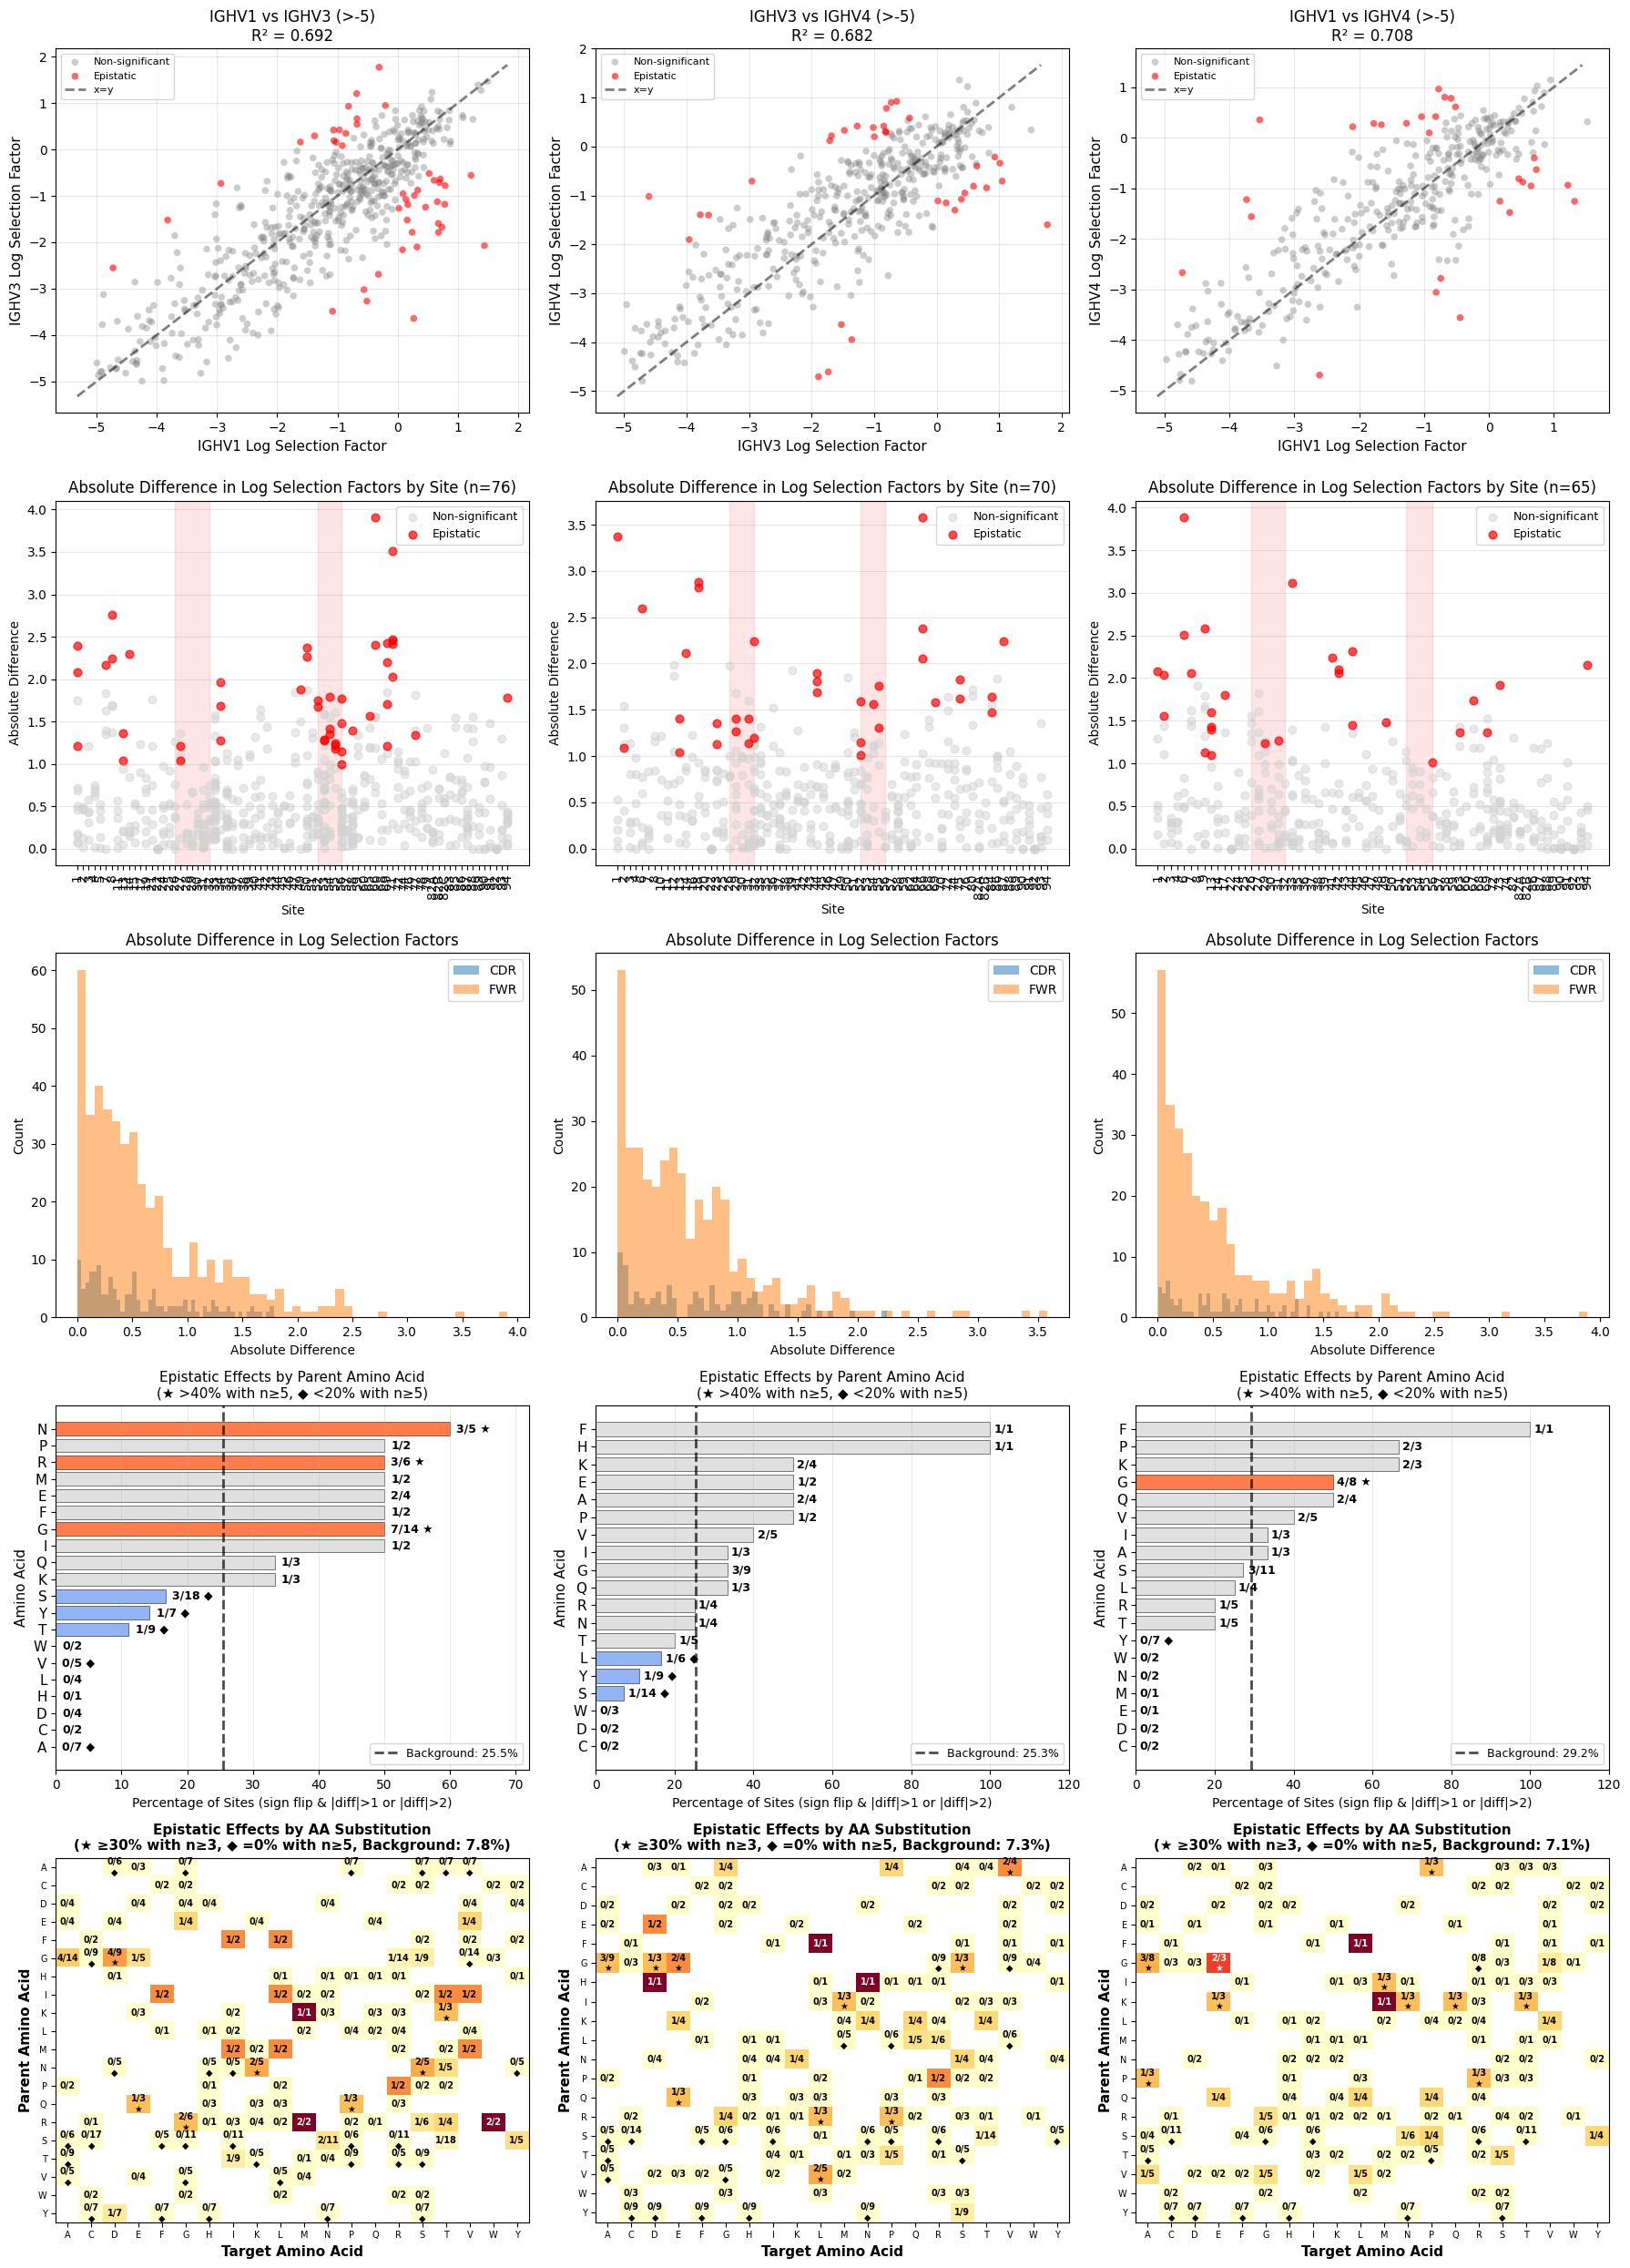

In [ ]:
def plot_all_pairwise_comparisons(
    df,
    comparisons=[('IGHV1', 'IGHV3'), ('IGHV3', 'IGHV4'), ('IGHV1', 'IGHV4')],
    vcolumn='v_family',
    is_germline=True,
    one_mutation_away=True,
    lower_log_selection_factor_lim=-5,
    limit_pcp_depth=True,
    figsize=None,
    include_heatmap=False
):
    """
    Creates a grid of subplots for multiple pairwise comparisons between V families.
    Each column is a comparison (e.g., IGHV1 vs IGHV3), and each row is a type of plot.

    Rows include:
    1. DASM regression (log selection factors correlation)
    2. DASM effect vs shift
    3. Site comparison (abs differences per site)
    4. Differences per region (CDR vs FWR)
    5. Epistasis by parent amino acid (bar plot)
    6. Epistasis by amino acid heatmap (optional, can be large)

    Parameters
    ----------
    df : DataFrame
        The amino acid site substitution selection data with necessary columns.
    comparisons : list of tuple
        List of (v_family1, v_family2) pairs to compare.
    vcolumn : str
        Column used for identifying V families (default 'v_family').
    is_germline : bool
        Passed to compare_v_families_group_1
    one_mutation_away : bool
        Passed to compare_v_families_group_1
    lower_log_selection_factor_lim : float
        Lower limit for filtering log selection factors
    limit_pcp_depth : bool
        Passed to compare_v_families_group_1
    figsize : tuple, optional
        Figure size. If None, automatically calculated based on number of comparisons.
    include_heatmap : bool, default False
        Whether to include the heatmap row (makes figure very tall)

    Returns
    -------
    fig : matplotlib.figure.Figure
    axes : numpy.ndarray
        2D array of axes objects
    comparison_data : dict
        Dictionary mapping comparison tuples to their DataFrames
    """
    
    n_comparisons = len(comparisons)
    n_rows = 5 if include_heatmap else 4
    
    # Auto-calculate figsize if not provided
    if figsize is None:
        width = 6 * n_comparisons
        height = 4 * n_rows if not include_heatmap else 5 * n_rows
        figsize = (width, height)
    
    # Create figure and axes
    fig, axes = plt.subplots(n_rows, n_comparisons, figsize=figsize)
    
    # Ensure axes is 2D even with single comparison
    if n_comparisons == 1:
        axes = axes.reshape(-1, 1)
    
    # Store comparison data for potential later use
    comparison_data = {}
    
    # Loop through each comparison
    for col_idx, (v_family1, v_family2) in enumerate(comparisons):
        print(f"Processing comparison: {v_family1} vs {v_family2}")
        
        # Get comparison data (assuming compare_v_families_group_1 exists)
        # You'll need to replace this with your actual data preparation function
        compare_df = compare_v_families_group_1(
            df,
            v_family1=v_family1,
            v_family2=v_family2,
            vcolumn=vcolumn,
            create_plots=False,
            is_germline=is_germline,
            one_mutation_away=one_mutation_away,
            lower_log_selection_factor_lim=lower_log_selection_factor_lim,
            limit_pcp_depth=limit_pcp_depth
        )
        
        comparison_data[(v_family1, v_family2)] = compare_df
        
        # Row 0: DASM regression
        ax, r_sq = plot_dasm_regression(
            compare_df,
            v_family1=v_family1,
            v_family2=v_family2,
            lower_log_selection_factor_lim=lower_log_selection_factor_lim,
            ax=axes[0, col_idx],
            apply_filter=True
        )
        
        # Row 1: Site comparison
        ax_site, _ = plot_site_comparison(
            compare_df,
            lower_log_selection_factor_lim=lower_log_selection_factor_lim,
            ax=axes[1, col_idx]
        )
        # # Adjust legend to prevent overflow
        # axes[1, col_idx].legend(bbox_to_anchor=(1.05, 1), loc='upper left', 
        #                         title='Parent AA', fontsize=8)
        
        # Row 2: Differences per region
        plot_differences_per_region(
            compare_df,
            ax=axes[2, col_idx]
        )
        
        # Row 3: Epistasis by amino acid
        ax_epi, _, _ = plot_epistasis_by_amino_acid_flagged(
            compare_df,
            figsize=(6, 5),  # This is ignored when ax is provided
            ax=axes[3, col_idx]
        )
        
        # Row 4: Epistasis heatmap (optional)
        if include_heatmap:
            ax_heat, _, _ = plot_epistasis_by_amino_acid_heatmap_flagged(
                compare_df,
                figsize=(12, 10),  # This is ignored when ax is provided
                ax=axes[4, col_idx]
            )
            # Make fonts smaller for heatmap in subplot
            axes[4, col_idx].tick_params(labelsize=7)
    
    # Adjust layout
    plt.tight_layout()
    
    return fig, axes, comparison_data



# Example 1: Full comparison grid (each comparison is a column)
fig, axes, data = plot_all_pairwise_comparisons(
    aa_site_subs_selection_df_germline,
    comparisons=[('IGHV1', 'IGHV3'), ('IGHV3', 'IGHV4'), ('IGHV1', 'IGHV4')],
    vcolumn='v_family',
    lower_log_selection_factor_lim=-5,
    include_heatmap=True  # Set True if you want heatmaps
)
plt.show()



## Group 2 sites

In [10]:
## for simplicity, let's compare v genes first 
def compare_group_2_sites_between_vgenes(aa_site_subs_selection_df_germline, germline_codons_df, 
                                         v_gene1, v_gene2, numbering_scheme='imgt', 
                                         one_mutation_away=False, limit_pcp_depth=True):
    '''
    Compare two v genes at sites and aas that are not common in both v genes.
    
    Parameters:
    -----------
    numbering_scheme : str
        Either 'imgt' or 'chothia' for CDR boundary definitions
    '''
    before_grouping = aa_site_subs_selection_df_germline.copy()
    if limit_pcp_depth:
        # Limit to only pcps that are 2 levels away from the naive, which are likely the most reliable
        before_grouping = before_grouping[before_grouping.depth == 2]

    if one_mutation_away:
        # Filter to only include mutations that are one mutation away        
        before_grouping = before_grouping[before_grouping['one_mutation_away'] == True]

    before_grouping = before_grouping[before_grouping.is_germline_codon == True]
    
    median_log_selection_factors_germline = before_grouping.groupby(['v_gene', 'site', 'parent_aa', 'selection_factor_target_aa', 'is_cdr']).log_selection_factor.median().reset_index().copy()
    
    # which sites and amino acids are we comparing - all group 2 sites and their possbile amino acids
    temp_df = pd.merge(germline_codons_df[germline_codons_df.v_gene == v_gene1], germline_codons_df[germline_codons_df.v_gene == v_gene2], on=['site', 'amino_acid'], how='outer', suffixes=('_1', '_2'))

    temp_df['is_common_germline_aa'] = (temp_df['codon_1'].isna() == False) & (temp_df['codon_2'].isna() == False)
    temp_df = temp_df[temp_df['is_common_germline_aa'] == False]
    v_gene_1_sites = temp_df[['site', 'amino_acid', 'v_gene_1']].dropna().drop_duplicates()
    v_gene_2_sites = temp_df[['site', 'amino_acid', 'v_gene_2']].dropna().drop_duplicates()
    
    # merge with median log selection factors
    median_log_selection_factors_germline.dropna(subset=['log_selection_factor'], inplace=True)
    median_log_selection_factors_1 = pd.merge(v_gene_1_sites.rename(columns={'v_gene_1':'v_gene', 'amino_acid':'parent_aa'}), median_log_selection_factors_germline, how='left', on=['site', 'parent_aa', 'v_gene', ])
    median_log_selection_factors_2 = pd.merge(v_gene_2_sites.rename(columns={'v_gene_2':'v_gene', 'amino_acid':'parent_aa'}), median_log_selection_factors_germline, how='left', on=['site', 'parent_aa', 'v_gene', ])

    # change the column names to describe selection direction
    median_log_selection_factors_1.rename(columns={'parent_aa':'parent_aa_1_and_target_aa_2', 'selection_factor_target_aa':'parent_aa_2_and_target_aa_1'}, inplace=True)
    median_log_selection_factors_2.rename(columns={'parent_aa':'parent_aa_2_and_target_aa_1', 'selection_factor_target_aa':'parent_aa_1_and_target_aa_2'}, inplace=True)

    compare_df = pd.merge(median_log_selection_factors_1, median_log_selection_factors_2, on=['site', 'parent_aa_1_and_target_aa_2', 'parent_aa_2_and_target_aa_1', 'is_cdr'], how='inner', suffixes=('_1', '_2'))
    plot_temp_df = pd.melt(compare_df, id_vars=['site', 'parent_aa_1_and_target_aa_2', 'parent_aa_2_and_target_aa_1', 'is_cdr'], value_vars=['log_selection_factor_1', 'log_selection_factor_2'], var_name='v_gene', value_name='log_selection_factor')

    # Sort sites properly
    sorted_sites = sort_antibody_sites(plot_temp_df['site'].unique())
    site_to_position = {site: i for i, site in enumerate(sorted_sites)}
    
    # === First plot: Bar plot ===
    fig, ax = plt.subplots(1, 1, figsize=(20, 5))
    
    # Add CDR shading
    add_cdr_shading(ax, sorted_sites, numbering_scheme=numbering_scheme)
    
    # Plot each hue group separately with position mapping
    for v_gene in plot_temp_df['v_gene'].unique():
        subset = plot_temp_df[plot_temp_df['v_gene'] == v_gene]
        x_positions = [site_to_position[site] for site in subset['site']]
        ax.bar(x_positions, subset['log_selection_factor'], 
               alpha=0.5, label=v_gene, width=0.8)

    ax.axhline(0, color='black', linestyle='--', linewidth=1)
    ax.set_xlabel('Site')
    ax.set_ylabel('Log Selection Factor')
    ax.legend()
    ax.grid(True, alpha=0.3, axis='y')
    
    # Set x-axis ticks to show site labels
    ax.set_xticks(range(len(sorted_sites)))
    ax.set_xticklabels(sorted_sites, rotation=90)

    # === Second plot: Sum scatter plot ===
    compare_df['sum'] = compare_df['log_selection_factor_1'] + compare_df['log_selection_factor_2']
    compare_df['is_entrenched'] = (compare_df['log_selection_factor_1'] < -1) & (compare_df['log_selection_factor_2'] < -1)

    fig, ax = plt.subplots(1, 1, figsize=(20, 6))
    
    # Add CDR shading
    add_cdr_shading(ax, sorted_sites, numbering_scheme=numbering_scheme)
    
    # Plot with color based on significance
    for is_sig in compare_df['is_entrenched'].unique():
        subset = compare_df[compare_df['is_entrenched'] == is_sig]
        subset_x = [site_to_position[site] for site in subset['site']]
        ax.scatter(subset_x, subset['sum'], 
                   alpha=0.7, label=f'entrenched: {is_sig}')
    
    ax.set_xlabel('Site')
    ax.set_ylabel('Sum of Log Selection Factors')
    ax.legend()
    ax.grid(True, alpha=0.3, axis='y')
    
    # Set x-axis ticks
    ax.set_xticks(range(len(sorted_sites)))
    ax.set_xticklabels(sorted_sites, rotation=90)

    # === Third plot: Correlation scatter ===
    fig, ax = plt.subplots(1, 1, figsize=(8, 5))
    
    # Create color map for sites
    unique_sites = sorted_sites
    colors = plt.cm.viridis(np.linspace(0, 1, len(unique_sites)))
    site_color_map = {site: colors[i] for i, site in enumerate(unique_sites)}
    
    for site in compare_df['site'].unique():
        subset = compare_df[compare_df['site'] == site]
        ax.scatter(subset['log_selection_factor_1'], 
                   subset['log_selection_factor_2'],
                   alpha=0.7, label=site, 
                   color=site_color_map[site])
    
    ax.set_xlabel('Log Selection Factor (V-gene 1)')
    ax.set_ylabel('Log Selection Factor (V-gene 2)')
    ax.axhline(0, color='gray', linestyle='--', alpha=0.5)
    ax.axvline(0, color='gray', linestyle='--', alpha=0.5)
    ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left', ncol=2, fontsize=8)
    ax.grid(True, alpha=0.3)
    plt.tight_layout()

    return compare_df


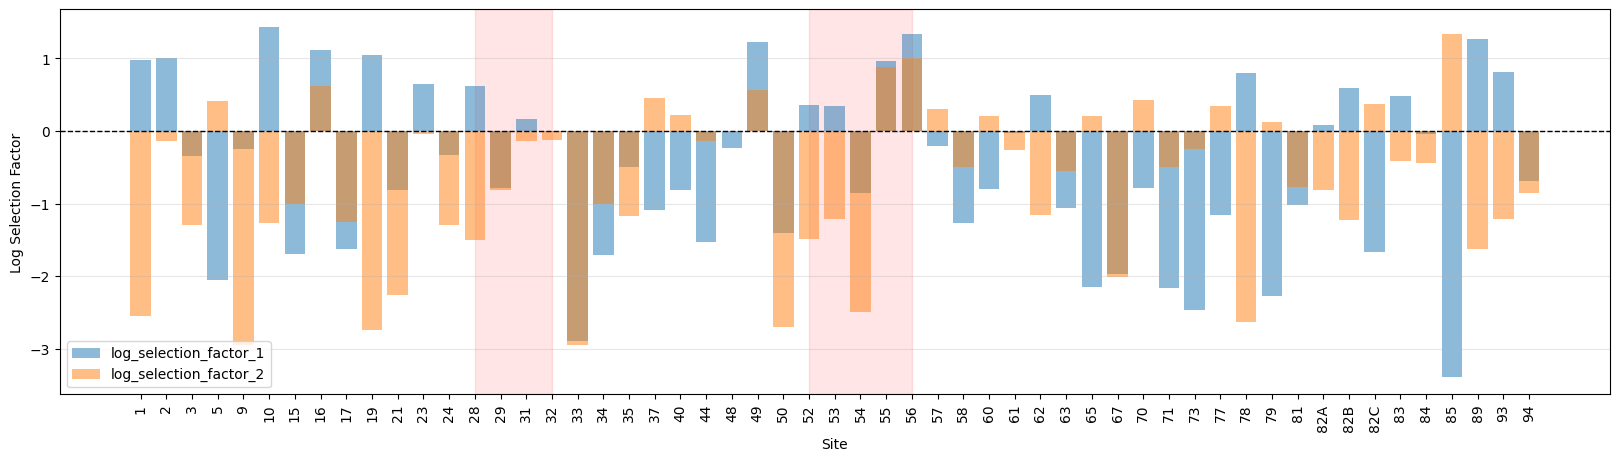

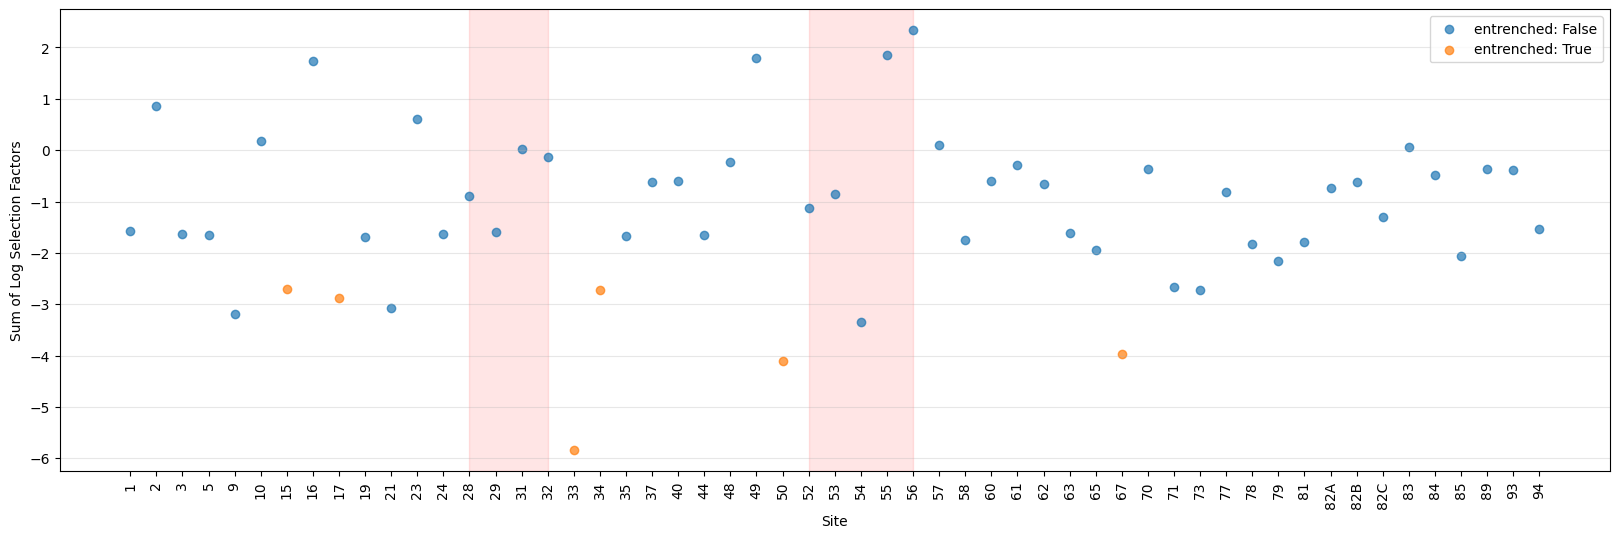

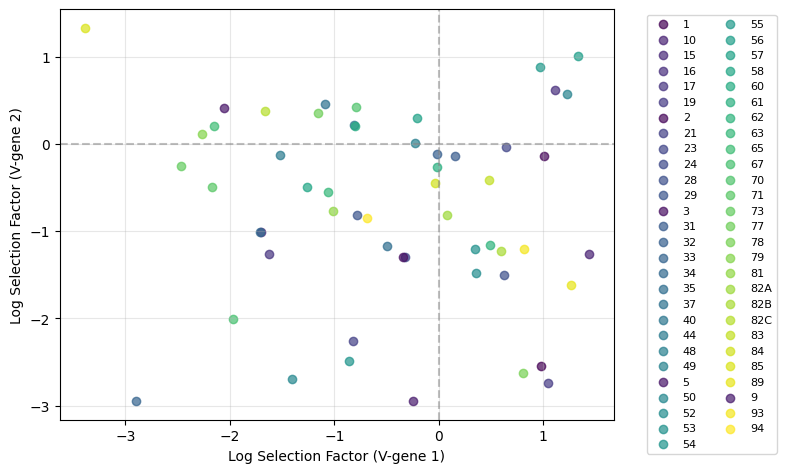

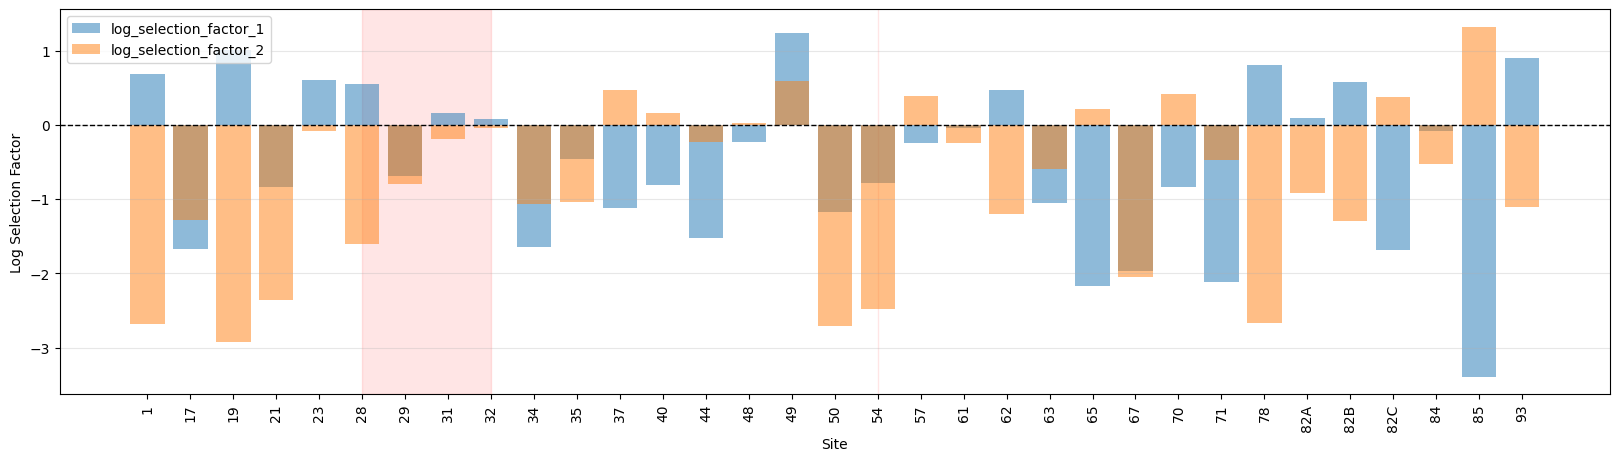

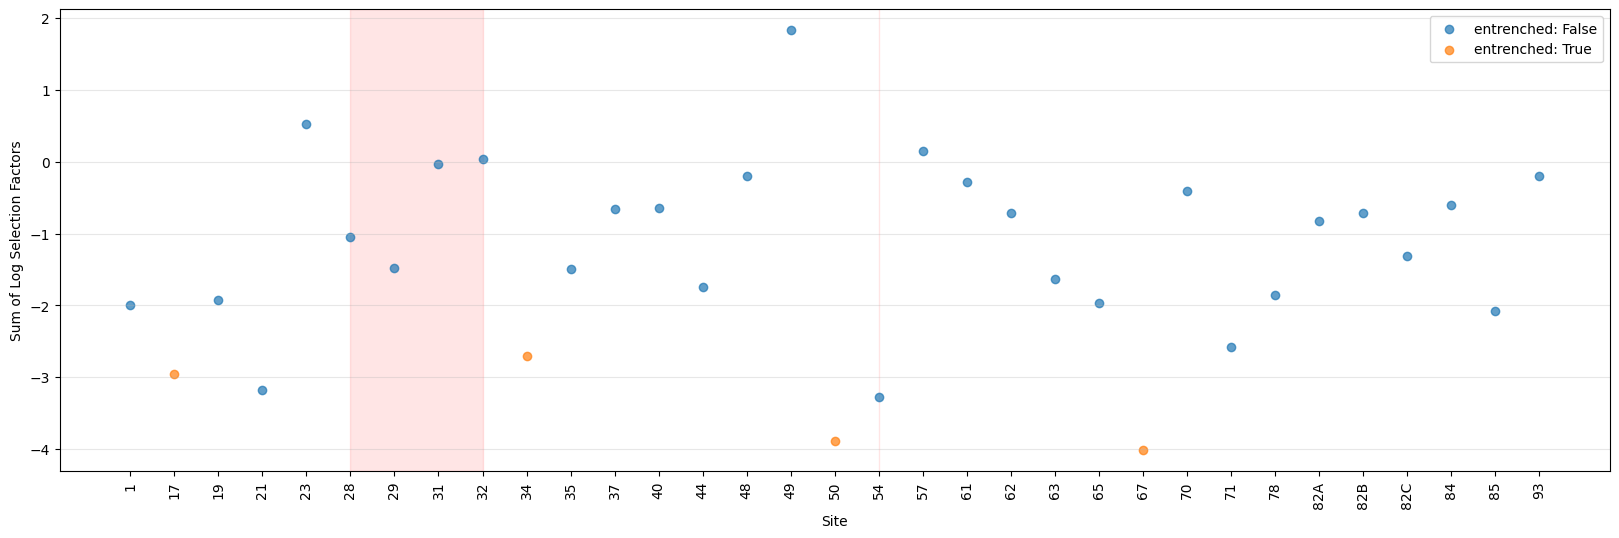

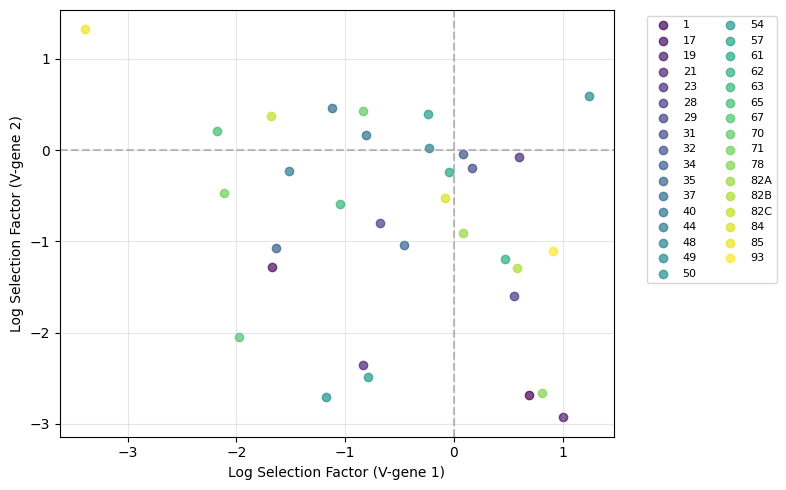

In [11]:
# permissive and strict option. Strict option limites for sites in which the two amino acids can be mutated one to the other in one mutation, and the only takes sequences that are the MRCA and thus should be under similar selective pressures.
temp_df = compare_group_2_sites_between_vgenes(aa_site_subs_selection_df_germline, germline_codons_df, 'IGHV3-15*01', 'IGHV2-5*02', one_mutation_away=False, limit_pcp_depth=False, numbering_scheme=numbering_scheme)
temp_df = compare_group_2_sites_between_vgenes(aa_site_subs_selection_df_germline, germline_codons_df, 'IGHV3-15*01', 'IGHV2-5*02', one_mutation_away=True, limit_pcp_depth=True, numbering_scheme=numbering_scheme)


In [12]:
### compare v families - separate function for within the same v family and between two different v families


def compare_group_2_sites_between_vfamilies_with_distribution(aa_site_subs_selection_df_germline, germline_codons_df, 
                                                              v_family1, v_family2, numbering_scheme='imgt',
                                                              one_mutation_away=True, limit_pcp_depth=True, remove_rare_aas=True,
                                                              figsize=(20, 7), save_results=False, threshold=-1):
    '''
    Compare two v families at sites and aas that are not common in both v genes to find entrenchment.
    Enhanced version with germline amino acid distribution plot below the scatter plot.
    
    Parameters:
    -----------
    numbering_scheme : str
        Either 'imgt' or 'chothia' for CDR boundary definitions
    '''
    # calculate and merge reciprocal selection factors for germline amino acids at each site
    before_grouping = aa_site_subs_selection_df_germline.copy()
    if limit_pcp_depth:
        before_grouping = before_grouping[before_grouping.depth == 2]

    if one_mutation_away:
        before_grouping = before_grouping[before_grouping['one_mutation_away'] == True]

    before_grouping = before_grouping[before_grouping.is_germline_codon == True]
    before_grouping.dropna(subset=['log_selection_factor'], inplace=True) # drop na in cases where Q>Q

    if remove_rare_aas:
        # filter to only include amino acids that are seen in more than 10 sequences in either family
        counts_of_aa_site_family = before_grouping[['v_family', 'site', 'parent_aa', 'pcp_index']].drop_duplicates().groupby(['v_family', 'site', 'parent_aa']).size().reset_index(name='count')
        counts_of_aa_site_family = counts_of_aa_site_family[counts_of_aa_site_family['count'] >= 10]
        before_grouping = pd.merge(before_grouping, counts_of_aa_site_family[['v_family', 'site', 'parent_aa']], on=['v_family', 'site', 'parent_aa'], how='inner')

    median_log_selection_factors_germline = before_grouping.groupby(['v_family', 'site', 'parent_aa', 'selection_factor_target_aa']).log_selection_factor.median().reset_index().copy()

    median_log_selection_factors_1 = median_log_selection_factors_germline[median_log_selection_factors_germline.v_family == v_family1].copy()
    median_log_selection_factors_2 = median_log_selection_factors_germline[median_log_selection_factors_germline.v_family == v_family2].copy()
    median_log_selection_factors_1.rename(columns={'parent_aa':'parent_aa_1_and_target_aa_2', 'selection_factor_target_aa':'parent_aa_2_and_target_aa_1'}, inplace=True)
    median_log_selection_factors_2.rename(columns={'parent_aa':'parent_aa_2_and_target_aa_1', 'selection_factor_target_aa':'parent_aa_1_and_target_aa_2'}, inplace=True)

    compare_df = pd.merge(median_log_selection_factors_1, median_log_selection_factors_2, on=['site', 'parent_aa_1_and_target_aa_2', 'parent_aa_2_and_target_aa_1'], how='inner', suffixes=('_1', '_2'))
    
    compare_df['sum'] = compare_df['log_selection_factor_1'] + compare_df['log_selection_factor_2']
    compare_df['is_entrenched'] = (compare_df['log_selection_factor_1'] < threshold) & (compare_df['log_selection_factor_2'] < threshold)


    if save_results:
        # Save the full comparison dataframe
        compare_df.to_csv(f'{output_dir}/comparison_{v_family1}_vs_{v_family2}.csv', index=False)
        
        # Save entrenched sites (where both < -1)
        if 'is_entrenched' in compare_df.columns:
            entrenched_df = compare_df[compare_df['is_entrenched'] == True].copy()
            
            # For v_family1 - get unique site/amino_acid/target_amino_acid combinations
            entrenched_aa_sites_vfam1 = entrenched_df[['v_family_1', 'site', 'parent_aa_1_and_target_aa_2', 'parent_aa_2_and_target_aa_1']]\
                .rename(columns={'v_family_1':'v_family', 'parent_aa_1_and_target_aa_2':'amino_acid', 'parent_aa_2_and_target_aa_1':'target_amino_acid'})\
                .drop_duplicates()\
                .sort_values(by='site')
            
            # For v_family2
            entrenched_aa_sites_vfam2 = entrenched_df[['v_family_2', 'site', 'parent_aa_2_and_target_aa_1', 'parent_aa_1_and_target_aa_2']]\
                .rename(columns={'v_family_2':'v_family', 'parent_aa_2_and_target_aa_1':'amino_acid', 'parent_aa_1_and_target_aa_2':'target_amino_acid'})\
                .drop_duplicates()\
                .sort_values(by='site')
            
            # Concatenate and save
            pd.concat([entrenched_aa_sites_vfam1, entrenched_aa_sites_vfam2]).sort_values(['v_family','site'])\
                .to_csv(f'{output_dir}/entrenched_aa_sites_{v_family1}_vs_{v_family2}.csv', index=False)


    # Get data for amino acid distribution
    family1_data = germline_codons_df[germline_codons_df.v_family == v_family1].copy()
    family2_data = germline_codons_df[germline_codons_df.v_family == v_family2].copy()
    
    # Get all sites and sort them properly
    all_sites_with_data = sorted(set(family1_data['site'].unique()) | set(family2_data['site'].unique()))
    sorted_sites = sort_antibody_sites(all_sites_with_data)
    site_to_position = {site: i for i, site in enumerate(sorted_sites)}
    
    # Check for data
    if len(sorted_sites) == 0:
        print("Warning: No data found for one or both V families")
        return compare_df, None, None
    
    # ===== CREATE COMBINED PLOT =====
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=figsize, 
                                   gridspec_kw={'height_ratios': [1, 1], 'hspace': 0.02})
    
    # ===== TOP PLOT: SCATTER PLOT =====
    # Add CDR shading first
    add_cdr_shading(ax1, sorted_sites, numbering_scheme=numbering_scheme)
    
    
    for is_sig in compare_df['is_entrenched'].unique():
        subset = compare_df[compare_df['is_entrenched'] == is_sig]
        subset_x = [site_to_position[site] for site in subset['site']]
        color = '#262626' if is_sig else '#D4D2D2'
        label = 'entrenched' if is_sig else 'not entrenched'
        ax1.scatter(subset_x, subset['sum'], 
                    alpha=0.85, label=label, color=color, edgecolor='black', linewidth=0.5)
    
    ax1.set_ylabel('Sum of\nlog selection factors', fontsize=17)
    ax1.tick_params(axis='y', labelsize=14)
    ax1.set_title(f'Entrenchment between {v_family1} and {v_family2}', fontsize=20)
    ax1.grid(True, axis='y', alpha=0.4, linewidth=0.8)
    for i in range(0, len(sorted_sites), 2):
        ax1.axvline(i, color='lightgray', alpha=0.4, linewidth=0.8)
    ax1.legend(bbox_to_anchor=(1.02, 0.8), loc='upper left', fontsize=17)
    
    # ===== BOTTOM PLOT: MIRRORED AMINO ACID DISTRIBUTION =====
    # Add CDR shading first
    add_cdr_shading(ax2, sorted_sites, numbering_scheme=numbering_scheme)
    
    # Calculate percentages for family1 at specific sites
    family1_site_counts = {}
    for aa in AA_STR_SORTED:
        aa_data = family1_data[family1_data['amino_acid'] == aa]
        site_counts = aa_data['site'].value_counts()
        family1_site_counts[aa] = site_counts
    
    # Calculate percentages for family2 at specific sites  
    family2_site_counts = {}
    for aa in AA_STR_SORTED:
        aa_data = family2_data[family2_data['amino_acid'] == aa]
        site_counts = aa_data['site'].value_counts()
        family2_site_counts[aa] = site_counts
    
    # Plot family1 above x-axis (positive values) - stack them
    for site in sorted_sites:
        site_pos = site_to_position[site]
        bottom1 = 0
        #site_total = sum([family1_site_counts[aa].get(site, 0) for aa in AA_STR_SORTED])
        site_total = family1_data['v_gene'].nunique()

        
        for aa in AA_STR_SORTED:
            count = family1_site_counts[aa].get(site, 0)
            if count > 0 and site_total > 0:
                percentage = (count / site_total) * 100
                ax2.bar(site_pos, percentage, bottom=bottom1, 
                       color=PALETTE_AA[aa], width=0.8, 
                       edgecolor='black', linewidth=0.5, align='center')
                bottom1 += percentage
    
    # Plot family2 below x-axis (negative values) - stack them
    for site in sorted_sites:
        site_pos = site_to_position[site]
        bottom2 = 0
        #site_total = sum([family2_site_counts[aa].get(site, 0) for aa in AA_STR_SORTED])
        site_total = family2_data['v_gene'].nunique()

        
        for aa in AA_STR_SORTED:
            count = family2_site_counts[aa].get(site, 0)
            if count > 0 and site_total > 0:
                percentage = -(count / site_total) * 100  # Negative for below x-axis
                ax2.bar(site_pos, percentage, bottom=bottom2, 
                       color=PALETTE_AA[aa], width=0.8, 
                       edgecolor='black', linewidth=0.5, align='center')
                bottom2 += percentage
    
    # Customize bottom plot
    ax2.set_ylabel(f'Germline AA\ndistribution\n\n', fontsize=17)
    ax2.axhline(y=0, color='black', linestyle='-', alpha=0.8, linewidth=1.5, zorder=0)
    # Add family labels to top and bottom halves
    ax2.text(-0.01, 0.75, v_family1, transform=ax2.transAxes, fontsize=16, ha='right', va='center', rotation=90)
    ax2.text(-0.01, 0.25, v_family2, transform=ax2.transAxes, fontsize=16, ha='right', va='center', rotation=90)

    
    # Create legend for amino acids
    legend_handles = []
    legend_labels = []
    for aa in AA_STR_SORTED:
        legend_handles.append(plt.Rectangle((0,0),1,1, facecolor=PALETTE_AA[aa], 
                                          edgecolor='black', linewidth=0.5))
        legend_labels.append(aa)
    
    ax2.legend(legend_handles, legend_labels, 
              bbox_to_anchor=(1.02, 1.2), loc='upper left', 
              ncol=2, fontsize=15, title='Amino Acids', title_fontsize=17)
    
    # Set x-axis for both plots
    ax1.set_xlim(-0.5, len(sorted_sites) - 0.5)
    ax2.set_xlim(-0.5, len(sorted_sites) - 0.5)
    
    # Set x-axis ticks - every other for grid, all for labels
    ax1.set_xticks(range(0, len(sorted_sites), 2))  # Grid at every other position
    ax2.set_xticks(range(len(sorted_sites)))
    
    # Only show x-tick labels on bottom plot
    ax1.set_xticklabels([])
    ax2.set_xlabel('Site position', fontsize=17)
    ax2.set_xticklabels(sorted_sites, rotation=90, fontsize=12)
    ax2.set_yticks([])
    
    plt.tight_layout()

    if save_results:
        fig.savefig(f'{output_dir}/{v_family1}_vs_{v_family2}_group2_sites_comparison.pdf', dpi=300, bbox_inches='tight')
    
    plt.show()

    plot_reciprocal_selection_factors_between_vfamilies(compare_df, v_family1, v_family2, save_results=save_results)

    return compare_df

def compare_group_2_sites_within_vfamily_with_distribution(aa_site_subs_selection_df_germline, germline_codons_df, 
                                                              v_family1, numbering_scheme='imgt',
                                                              one_mutation_away=True, limit_pcp_depth=True, remove_rare_aas=True,
                                                              figsize=(20, 7), save_results=False, threshold=-1):
    '''
    Compare within v families at sites that have more than one possible aa to find entrenchment.
    Enhanced version with germline amino acid distribution plot below the scatter plot.
    
    Parameters:
    -----------
    numbering_scheme : str
        Either 'imgt' or 'chothia' for CDR boundary definitions
    '''
    # calculate and merge reciprocal selection factors for germline amino acids at each site
    before_grouping = aa_site_subs_selection_df_germline.copy()
    if limit_pcp_depth:
        before_grouping = before_grouping[before_grouping.depth == 2]

    if one_mutation_away:
        before_grouping = before_grouping[before_grouping['one_mutation_away'] == True]

    before_grouping = before_grouping[before_grouping.is_germline_codon == True]
    before_grouping.dropna(subset=['log_selection_factor'], inplace=True) # drop na in cases where Q>Q

    if remove_rare_aas:
        # filter to only include amino acids that are seen in more than 10 sequences in either family
        counts_of_aa_site_family = before_grouping[['v_family', 'site', 'parent_aa', 'pcp_index']].drop_duplicates().groupby(['v_family', 'site', 'parent_aa']).size().reset_index(name='count')
        counts_of_aa_site_family = counts_of_aa_site_family[counts_of_aa_site_family['count'] >= 10]
        before_grouping = pd.merge(before_grouping, counts_of_aa_site_family[['v_family', 'site', 'parent_aa']], on=['v_family', 'site', 'parent_aa'], how='inner')

    median_log_selection_factors_germline = before_grouping.groupby(['v_family', 'site', 'parent_aa', 'selection_factor_target_aa']).log_selection_factor.median().reset_index().copy()

    median_log_selection_factors_1 = median_log_selection_factors_germline[median_log_selection_factors_germline.v_family == v_family1].copy()
    median_log_selection_factors_2 = median_log_selection_factors_1.copy()
    median_log_selection_factors_1.rename(columns={'parent_aa':'parent_aa_1_and_target_aa_2', 'selection_factor_target_aa':'parent_aa_2_and_target_aa_1'}, inplace=True)
    median_log_selection_factors_2.rename(columns={'parent_aa':'parent_aa_2_and_target_aa_1', 'selection_factor_target_aa':'parent_aa_1_and_target_aa_2'}, inplace=True)

    compare_df = pd.merge(median_log_selection_factors_1, median_log_selection_factors_2, on=['site', 'parent_aa_1_and_target_aa_2', 'parent_aa_2_and_target_aa_1'], how='inner', suffixes=('_1', '_2'))
    
    compare_df['sum'] = compare_df['log_selection_factor_1'] + compare_df['log_selection_factor_2']
    compare_df['is_entrenched'] = (compare_df['log_selection_factor_1'] < threshold) & (compare_df['log_selection_factor_2'] < threshold)

    if save_results:
        # Save the full comparison dataframe
        compare_df.to_csv(f'{output_dir}/comparison_within_{v_family1}.csv', index=False)
        
        # Save entrenched sites (where both < -1)
        if 'is_entrenched' in compare_df.columns:
            entrenched_df = compare_df[compare_df['is_entrenched'] == True].copy()
            
            # Get sites and amino acids that show entrenchment within a v family
            entrenched_aa_sites = entrenched_df[['v_family_1', 'site', 'parent_aa_1_and_target_aa_2', 'parent_aa_2_and_target_aa_1']]\
                .rename(columns={'v_family_1':'v_family', 'parent_aa_1_and_target_aa_2':'amino_acid', 'parent_aa_2_and_target_aa_1':'target_amino_acid'})\
                .drop_duplicates()\
                .sort_values(by='site')
            
            # Save
            entrenched_aa_sites.to_csv(f'{output_dir}/entrenched_aa_sites_within_{v_family1}.csv', index=False)



    # Get data for amino acid distribution
    family1_data = germline_codons_df[germline_codons_df.v_family == v_family1].copy()
    
    # Get all sites and sort them properly
    all_sites_with_data = sorted(set(family1_data['site'].unique()))
    sorted_sites = sort_antibody_sites(all_sites_with_data)
    site_to_position = {site: i for i, site in enumerate(sorted_sites)}
    
    # Check for data
    if len(sorted_sites) == 0:
        print("Warning: No data found for one or both V families")
        return compare_df, None, None
    
    # ===== CREATE COMBINED PLOT =====
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=figsize, 
                                   gridspec_kw={'height_ratios': [1, 1], 'hspace': 0.02})
    
    # ===== TOP PLOT: SCATTER PLOT =====
    # Add CDR shading first
    add_cdr_shading(ax1, sorted_sites, numbering_scheme=numbering_scheme)
    
    for is_sig in compare_df['is_entrenched'].unique():
        subset = compare_df[compare_df['is_entrenched'] == is_sig]
        # because compares within v family, there is duplication of the aa combinations (A->D and D->A) - we can drop the duplicates for plotting
        subset = subset[subset.parent_aa_1_and_target_aa_2 < subset.parent_aa_2_and_target_aa_1]
        
        subset_x = [site_to_position[site] for site in subset['site']]
        color = '#262626' if is_sig else '#D4D2D2'
        label = 'entrenched' if is_sig else 'not entrenched'
        ax1.scatter(subset_x, subset['sum'], 
                    alpha=0.85, label=label, color=color, edgecolor='black', linewidth=0.5)
    
    ax1.set_ylabel('Sum of\nlog selection factors', fontsize=17)
    ax1.tick_params(axis='y', labelsize=14)
    ax1.set_title(f'Entrenchment within {v_family1}', fontsize=20)
    ax1.grid(True, axis='y', alpha=0.4, linewidth=0.8)
    for i in range(0, len(sorted_sites), 2):
        ax1.axvline(i, color='lightgray', alpha=0.4, linewidth=0.8)
    ax1.legend(bbox_to_anchor=(1.02, 0.8), loc='upper left', fontsize=17)
    
    # ===== BOTTOM PLOT: MIRRORED AMINO ACID DISTRIBUTION =====
    # Add CDR shading first
    add_cdr_shading(ax2, sorted_sites, numbering_scheme=numbering_scheme)
    
    # Calculate percentages for family1 at specific sites
    family1_site_counts = {}
    for aa in AA_STR_SORTED:
        aa_data = family1_data[family1_data['amino_acid'] == aa]
        site_counts = aa_data['site'].value_counts()
        family1_site_counts[aa] = site_counts
    
    # Plot family1 above x-axis (positive values) - stack them
    for site in sorted_sites:
        site_pos = site_to_position[site]
        bottom1 = 0
        #site_total = sum([family1_site_counts[aa].get(site, 0) for aa in AA_STR_SORTED])
        site_total = family1_data['v_gene'].nunique()
        
        for aa in AA_STR_SORTED:
            count = family1_site_counts[aa].get(site, 0)
            if count > 0 and site_total > 0:
                percentage = (count / site_total) * 100
                ax2.bar(site_pos, percentage, bottom=bottom1, 
                       color=PALETTE_AA[aa], width=0.8, 
                       edgecolor='black', linewidth=0.5, align='center')
                bottom1 += percentage
    
    # Customize bottom plot
    ax2.set_ylabel(f'Germline AA\ndistribution\n', fontsize=17)
    ax2.axhline(y=0, color='black', linestyle='-', alpha=0.8, linewidth=1, zorder=0)
    
    # Create legend for amino acids
    legend_handles = []
    legend_labels = []
    for aa in AA_STR_SORTED:
        legend_handles.append(plt.Rectangle((0,0),1,1, facecolor=PALETTE_AA[aa], 
                                          edgecolor='black', linewidth=0.5))
        legend_labels.append(aa)
    
    ax2.legend(legend_handles, legend_labels, bbox_to_anchor=(1.02, 1.2), loc='upper left', 
              title='Amino Acids', fontsize=15, title_fontsize=17, ncol=2)
    
    # Set x-axis for both plots
    ax1.set_xlim(-0.5, len(sorted_sites) - 0.5)
    ax2.set_xlim(-0.5, len(sorted_sites) - 0.5)
    
    # Set x-axis ticks - every other for grid, all for labels
    ax1.set_xticks(range(0, len(sorted_sites), 2))  # Grid at every other position
    ax2.set_xticks(range(len(sorted_sites)))
    
    # Only show x-tick labels on bottom plot
    ax1.set_xticklabels([])
    ax2.set_xlabel('Site position', fontsize=17)
    ax2.set_xticklabels(sorted_sites, rotation=90, fontsize=12)
    ax2.set_yticks([])
    
    plt.tight_layout()

    if save_results:
        fig.savefig(f'{output_dir}/within_{v_family1}_group2_sites_comparison.pdf', dpi=300, bbox_inches='tight')
    
    plt.show()

    plot_reciprocal_selection_factors_within_vfamily(compare_df, v_family1, save_results=save_results)

    return compare_df

def plot_reciprocal_selection_factors_within_vfamily(compare_df, v_family, save_results=False):
    fig, ax = plt.subplots(1, 1, figsize=(7, 4))
    
    for is_sig in compare_df['is_entrenched'].unique():
        subset = compare_df[compare_df['is_entrenched'] == is_sig]
        subset = subset[subset.parent_aa_1_and_target_aa_2 < subset.parent_aa_2_and_target_aa_1] # because compares within v family, there is duplication of the aa combinations (A->D and D->A) - we can drop the duplicates for plotting
        color = '#262626' if is_sig else '#D4D2D2'
        label = 'entrenched' if is_sig else 'not entrenched'
        ax.scatter(subset['log_selection_factor_1'], 
                   subset['log_selection_factor_2'],
                   alpha=0.85, label=label, color=color, edgecolor='black', linewidth=0.5)
    
    ax.set_xlabel(r'$f_j(A \to B)$')
    ax.set_ylabel(r'$f_j(B \to A)$')
    ax.axhline(0, color='gray', linestyle='--', alpha=0.5)
    ax.axvline(0, color='gray', linestyle='--', alpha=0.5)
    ax.set_title(v_family)
    ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    ax.set_xlim(-4.2, 2)
    ax.set_ylim(-4.2, 2)
    ax.grid(True, alpha=0.3)
    plt.tight_layout(rect=[0, 0, 0.85, 1])
    if save_results:
        fig.savefig(f'{output_dir}/within_{v_family}_group2_sites_reciprocal_selection.pdf', dpi=300, bbox_inches='tight')
    plt.show()


def plot_reciprocal_selection_factors_between_vfamilies(compare_df, v_family1, v_family2, save_results=False):
    fig, ax = plt.subplots(1, 1, figsize=(7, 4))
    
    for is_sig in compare_df['is_entrenched'].unique():
        subset = compare_df[compare_df['is_entrenched'] == is_sig]
        color = '#262626' if is_sig else '#D4D2D2'
        label = 'entrenched' if is_sig else 'not entrenched'
        ax.scatter(subset['log_selection_factor_1'], 
                   subset['log_selection_factor_2'],
                   alpha=0.85, label=label, color=color, edgecolor='black', linewidth=0.5)
    
    ax.set_xlabel(f'{v_family1} ' + r'$f_j(A \to B)$')
    ax.set_ylabel(f'{v_family2} ' + r'$f_j(B \to A)$')
    ax.axhline(0, color='gray', linestyle='--', alpha=0.5)
    ax.axvline(0, color='gray', linestyle='--', alpha=0.5)
    ax.set_title(f'{v_family1} vs {v_family2}')
    ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    ax.set_xlim(-4.2, 2)
    ax.set_ylim(-4.2, 2)
    ax.grid(True, alpha=0.3)
    plt.tight_layout(rect=[0, 0, 0.85, 1])
    if save_results:
        fig.savefig(f'{output_dir}/{v_family1}_vs_{v_family2}_group2_sites_reciprocal_selection.pdf', dpi=300, bbox_inches='tight')
    plt.show()



def plot_annotated_mutation_comparison(temp_df, site_list, figsize=(10, 8)):
    """
    Create a scatter plot comparing log selection factors with mutation annotations.
    
    Parameters:
    -----------
    temp_df : pandas.DataFrame
        DataFrame containing comparison data with columns:
        - 'parent_aa_1_and_target_aa_2'
        - 'parent_aa_2_and_target_aa_1' 
        - 'site'
        - 'log_selection_factor_1'
        - 'log_selection_factor_2'
    site_list : list
        List of site numbers to include in the plot
    figsize : tuple, optional
        Figure size as (width, height). Default is (10, 8)
    
    Returns:
    --------
    fig, ax : matplotlib figure and axes objects
    """
    
    # Create a copy to avoid modifying the original dataframe
    df_copy = temp_df.copy()
    
    # Create the full mutation labels
    df_copy['full_mutation'] = (df_copy['parent_aa_1_and_target_aa_2'] + 
                               df_copy['site'].astype(str) + 
                               df_copy['parent_aa_2_and_target_aa_1'])
    
    # Filter data for specific sites
    plot_data = df_copy[df_copy.site.isin(site_list)]
    
    if plot_data.empty:
        print(f"Warning: No data found for sites {site_list}")
        return None, None
    
    # Create the scatter plot with site-based coloring
    fig, ax = plt.subplots(figsize=figsize)
    sns.scatterplot(data=plot_data, x='log_selection_factor_1', y='log_selection_factor_2', 
                    alpha=0.7, s=100, ax=ax, hue='site', palette='tab10')
    
    # Add annotations for each point
    for idx, row in plot_data.iterrows():
        ax.annotate(row['full_mutation'], 
                    (row['log_selection_factor_1'], row['log_selection_factor_2']),
                    xytext=(5, 5),  # offset from point (x, y pixels)
                    textcoords='offset points',
                    fontsize=9,
                    ha='left',  # horizontal alignment
                    va='bottom',  # vertical alignment
                    bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.7),  # background box
                    arrowprops=dict(arrowstyle='->', connectionstyle='arc3,rad=0'))
    
    # Customize the plot
    ax.set_xlabel('Log Selection Factor 1')
    ax.set_ylabel('Log Selection Factor 2')
    
    # Create title based on site list
    if len(site_list) == 1:
        title = f'Log Selection Factors Comparison - Site {site_list[0]}'
    elif len(site_list) <= 5:
        title = f'Log Selection Factors Comparison - Sites {", ".join(map(str, site_list))}'
    else:
        title = f'Log Selection Factors Comparison - {len(site_list)} Sites'
    
    ax.set_title(title)
    ax.grid(True, alpha=0.3)
    
    # Add reference lines
    ax.axline((0, 0), slope=-1, color='red', linestyle='--', alpha=0.5, label='y=-x')
    ax.axhline(y=0, color='black', linestyle='-', alpha=0.5, linewidth=1)
    ax.axvline(x=0, color='black', linestyle='-', alpha=0.5, linewidth=1)
    ax.legend()
    
    plt.tight_layout()
    plt.show()
    
    return fig, ax

/tmp/ipykernel_3544297/1734006402.py:197: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


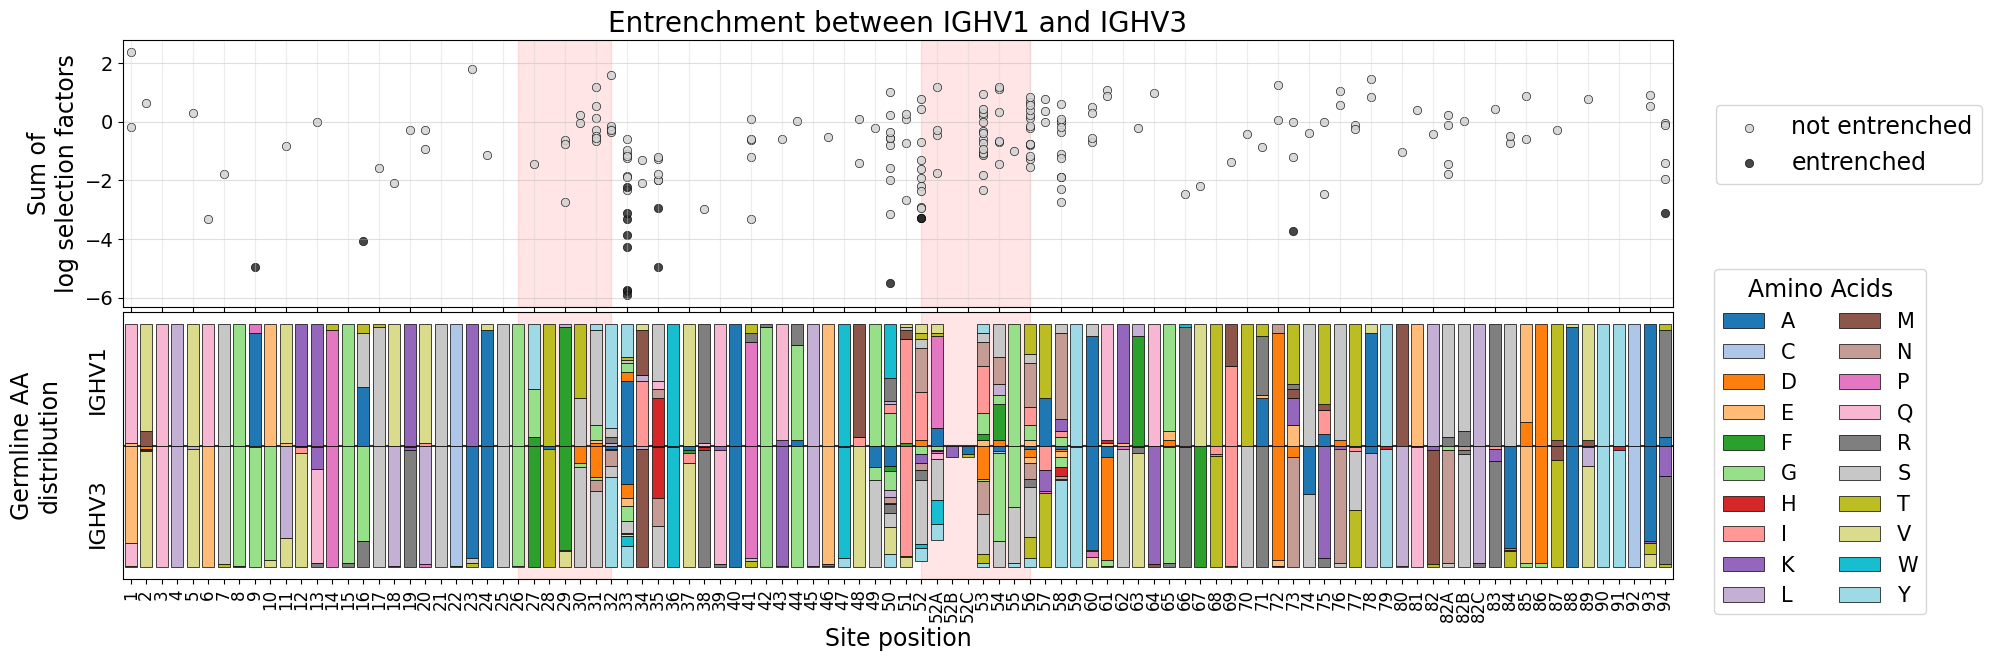

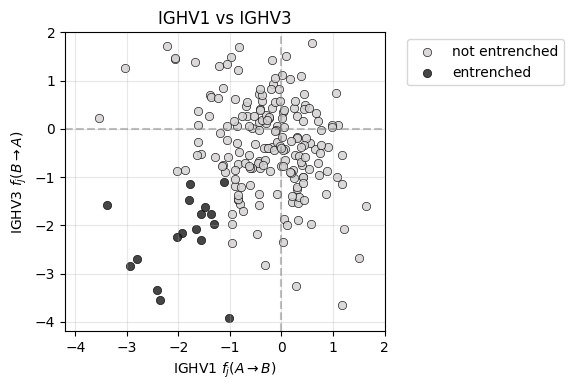

/tmp/ipykernel_3544297/1734006402.py:197: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


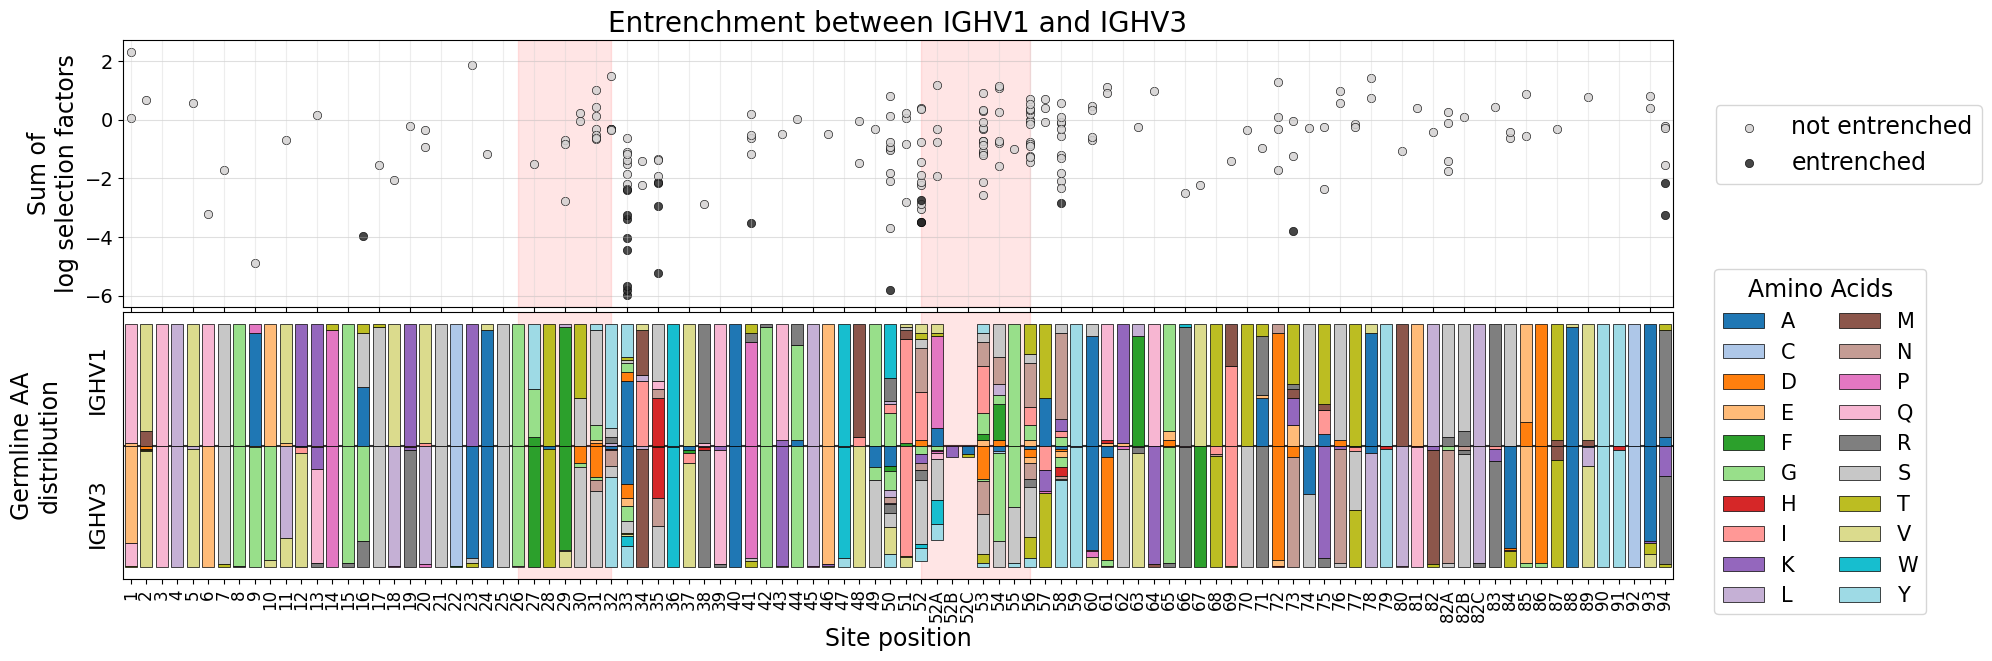

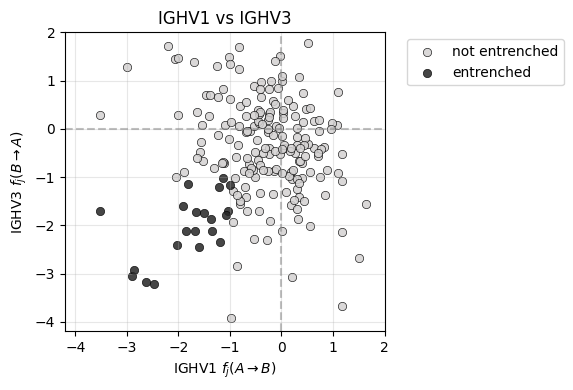

In [13]:
# compare v1 to v3 with and without limiting on MRCA seqences - does not seem to change the analysis much

temp_df = compare_group_2_sites_between_vfamilies_with_distribution(
    aa_site_subs_selection_df_germline, germline_codons_df, 'IGHV1', 'IGHV3', 
    one_mutation_away=True, limit_pcp_depth=True, numbering_scheme=numbering_scheme, 
)

temp_df = compare_group_2_sites_between_vfamilies_with_distribution(
    aa_site_subs_selection_df_germline, germline_codons_df, 'IGHV1', 'IGHV3', 
    one_mutation_away=True, limit_pcp_depth=False, numbering_scheme=numbering_scheme,
)


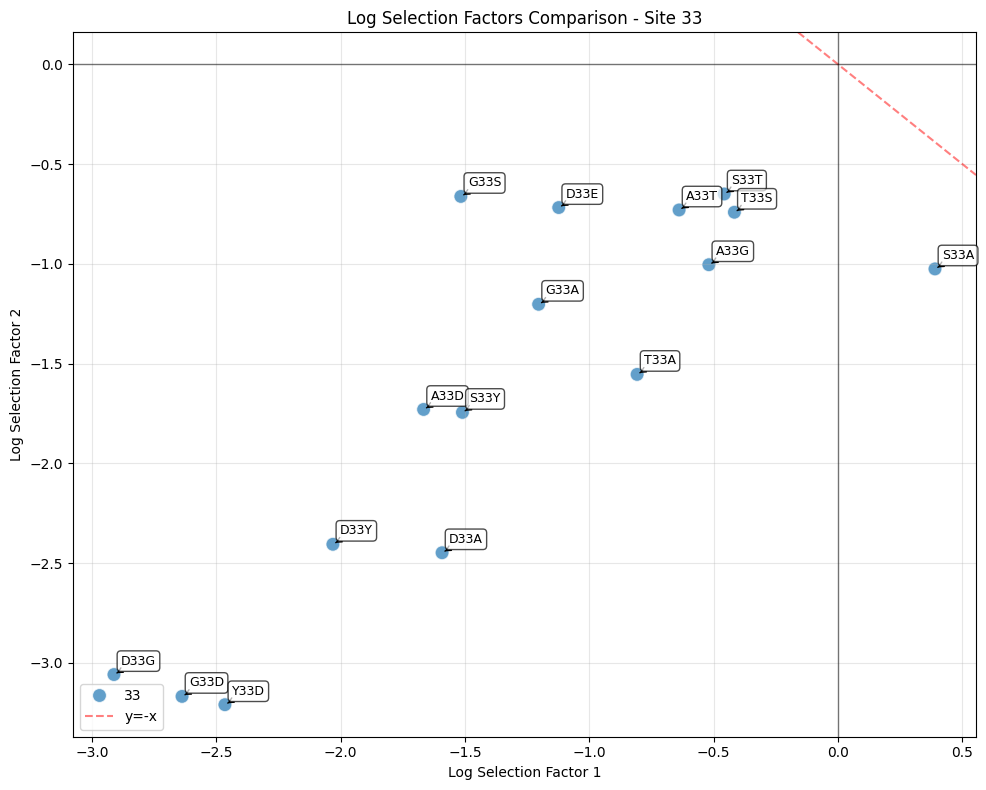

In [14]:
fig, ax = plot_annotated_mutation_comparison(temp_df, ['33'])